<a href="https://colab.research.google.com/github/skumova/bist-100-teknik-analiz-ve-filtreleme-i-yi.ipynb/blob/claude%2Fbist-fundamental-analysis-DidrQ/BIST_Deep_Value_Contrarian_Tarama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📉➡️📈 BIST Derin Değer & Kontraryan Dip Avcısı

**Momentum kovalamayan, "aşırı ucuz kalmış ama çürük olmayan" hisseyi avlayan tarama.**

> *30 yıllık BIST tüccarı mantığı: "Malı ucuza almak kazandırır — ama sadece mal sağlamsa.
> Ucuz + çürük = değer tuzağı. Bütün maharet, ucuz-ve-sağlam ile ucuz-çünkü-batıyor'u ayırmakta."*

---

## Neden bu strateji? (Felsefe)

Bu depodaki mevcut bot (`src/scanner.py`, `src/model.py`) bir **momentum/trend-takip**
sistemidir: ADX>20, EMA hizası, yukarı kırılım, XGBoost yön tahmini. Yani **yükselişi kovalar**.

Bu notebook bunun **tam tersi** felsefeyi kurgular:

| | Momentum botu (mevcut) | Bu tarama (kontraryan derin değer) |
|---|---|---|
| Ne arar? | Yükselen, ivmeli hisse | Dövülmüş, aşırı satımda, terk edilmiş hisse |
| Ne zaman alır? | Kırılımda, kalabalıkla | Panikte, kalabalığın tersine, kademeli |
| Risk | Zirveye yakın alım | "Düşen bıçak" (kademeli alım + stop ile yönetilir) |
| Kâr mantığı | Trend devam eder | Ortalamaya dönüş + değerin fiyatı yakalaması |

**Ana belirleyici = TEKNİK göstergeler.** Bir hissenin ne kadar "aşırı ucuz" olduğunu teknik
ölçer ve sıralar. **Banker (akıllı para) + temel göstergeler ise ÜSTÜNE ekstra puanlama**
katmanıdır — çürük malı eler, sağlam olanı öne çıkarır. Alım tarafında ise **Fibonacci ile
3 kademeli alım** planı kurulur.


## 🏗️ Mimari — nasıl puanlıyoruz?

```
        ┌──────────────────────── ÇEKİRDEK ──────────────────────────┐
   OHLCV│  TEKNİK UCUZLUK (0-100) — SIRALAMAYI YALNIZCA BU BELİRLER    │──► ÇEKİRDEK
   ───► │   52h dip konumu·RSI(g+h)·drawdown·Bollinger%B·200EMA·W%R    │    + "aşırı ucuz"
        │   (backtest: sade teknik corr(ileri getiri)=+0.32, kanıtlı)  │      KAPISI: teknik≥60
        └─────────────────────────────────────────────────────────────┘
                                     ×
        ┌───────────────────── ZAMANLAMA TEYİDİ ──────────────────────┐
   Hacim│  BANKER / AKILLI PARA (dönüş/birikim) → çarpan ±%15          │
   ───► │   A-D·OBV eğimi · CMF/MFI DÖNÜŞÜ · pozitif diverjans          │
        │  + POZİTİF RSI DİVERJANSI → çarpan +%8 (en güçlü tekil sinyal)│
        └─────────────────────────────────────────────────────────────┘
                                     ×
        ┌─────────────────────────────────────────────────────────────┐
   İş Y.│  TEMEL DEĞER & KALİTE → yalnızca PUANLAMA KATKISI (±%20)      │
   / yf │   PD/DD·EV/EBITDA·F/K·DCF güvenlik marjı·owner earnings       │
   ───► │   temel_çarpan = 1 + 0.20×(temel−50)/50   (≈0.80–1.20)       │
        └─────────────────────────────────────────────────────────────┘
                                     ×
        ┌─────────────────────────────────────────────────────────────┐
   Temel│  VALUE-TRAP CEZASI (çarpan 0.3×–0.8× / diskalifiye)           │
   ───► │   nakit yakma·zarar·DCF pahalı·likidite·"ucuz çünkü batıyor"  │
        └─────────────────────────────────────────────────────────────┘
                                     ↓
   NİHAİ = TEKNİK × zamanlama_teyidi × temel_çarpan × trap_çarpanı   (yüksek = al)
                                     ↓
              Seçilenlere → FIBONACCI 3-KADEME ALIM MERDİVENİ
```

**Sıralamayı yalnızca teknik ucuzluk belirler — bu bir backtest bulgusu.** Point-in-time
(look-ahead'siz) backtest'te teknik ucuzluğun ileriye dönük 40-gün getiriyle korelasyonu
**+0.32**; banker'ı çekirdeğe %40 katmak bunu **+0.23'e düşürüyordu** — çünkü banker'ın
eski *seviye*-tabanlı hâli ucuzlukla ters çalışıyordu (corr −0.56, dövülmüş hissede para-akışı
seviyesi düşük olur). Bu yüzden **banker yeniden *dönüş/birikim* odaklı** kuruldu (seviye değil:
son ~5 barda akım toparlıyor mu, fiyat düşerken A-D/OBV yükseliyor mu) ve pozitif RSI
diverjansıyla birlikte yalnızca küçük bir **zamanlama teyit çarpanı**na indirildi. Böylece
"birikim başlamış ucuz hisse" **elenmez, hafifçe öne çıkar** ama kanıtlı teknik sinyali ezmez.
Yeni tasarımda birikim (accumulation) bayrağı, ucuz havuzda **+%5.5** ileri-getiri avantajı
gösterdi. **Temel kriterler** ±%20 ince ayar; **value-trap** çürük malı ağır cezalar / tamamen eler.


## 1) Kurulum

Bu notebook **tamamen kendine-yeterdir**: motor kodu doğrudan hücrelere yazılıdır —
`src/` importu, repo klonu, base64 YOK. Veri kaynağı, bu depodaki **çalışan** HMM/Intraday
notebook'larıyla **aynı kanıtlanmış desen**: **tvdatafeed (rongardF fork)** → `TvDatafeed()`
misafir modda, `tv.get_hist(sembol, "BIST", Interval.in_daily, n_bars)`. yfinance yalnızca
tek tük sembolde yedektir. Temel oranlar: İş Yatırım → yfinance.

In [1]:
# === KURULUM (sizin çalışan notebook'larınızla aynı sade desen) ===
import subprocess, sys, warnings, logging
warnings.filterwarnings("ignore")

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

for pkg, imp in [("git+https://github.com/rongardF/tvdatafeed.git", "tvDatafeed"),
                 ("yfinance", "yfinance"), ("openpyxl", "openpyxl"),
                 ("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib"),
                 ("requests", "requests"), ("borsapy", "borsapy")]:   # borsapy: doğru BIST sektörleri
    try:
        __import__(imp)
    except ImportError:
        print(f"{imp} kuruluyor…")
        _pip(pkg)

# Gürültülü kaynak loglarını sustur (yüzlerce sembolde çıktı seli = Colab donması)
for _n in ("tvDatafeed", "tvDatafeed.main", "websocket", "yfinance", "urllib3"):
    logging.getLogger(_n).setLevel(logging.CRITICAL)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
print("✅ Kurulum tamam.")

tvDatafeed kuruluyor…
borsapy kuruluyor…
✅ Kurulum tamam.


### Puanlama motoru (inline)

Aşağıdaki hücre tüm puanlama motorunu (teknik ucuzluk, banker/akıllı para, temel değer &
kalite, value-trap, birleşik skor, Fibonacci merdiveni) notebook'a tanımlar. Değiştirmenize
gerek yok; parametreler `TECH_GATE`, `BANKER_BONUS_STRENGTH`, `RSI_DIV_BONUS`,
`FUND_BONUS_STRENGTH`, `TECH_WEIGHTS` vb. bu hücrededir.

**Mimari (backtest ile doğrulandı):** Sıralamayı **yalnızca teknik ucuzluk** (çekirdek)
belirler — point-in-time backtest'te banker'ı çekirdeğe %40 katmak öngörüyü zayıflatıyordu
(corr +0.23 vs sade teknik +0.32). Banker artık **dönüş/birikim** odaklı (seviye değil) ve
pozitif RSI diverjansıyla birlikte yalnızca küçük bir **zamanlama teyit çarpanı**dır. Böylece
"birikim başlamış ucuz hisse" elenmez, hafifçe öne çıkar; kanıtlı teknik sinyal ezilmez.

In [2]:
# ==================== PUANLAMA MOTORU (inline) ====================
"""
src/deep_value.py
==================

BIST "Derin Değer & Kontraryan Dip Avcısı" motoru.

Felsefe
-------
Bu modül, mevcut momentum/trend-takip botunun (src/scanner.py, src/model.py)
TAM TERSİ bir bakış açısını kodlar:

    "Yükselişi / momentumu kovalamak yerine, TEKNİK olarak aşırı dövülmüş
     (ucuz kalmış) ama TEMEL olarak çürük OLMAYAN hisseleri avla."

"Malı ucuza almak kazandırır" prensibi — AMA sadece mal sağlamsa. Ucuz + çürük
= değer tuzağı (value trap). Bütün mesele, "ucuz-ve-sağlam" ile
"ucuz-çünkü-batıyor"u ayırmaktır. Bu yüzden iki BAĞIMSIZ eksende puanlarız ve
ikisini de geçmeyen eleniyor:

    Eksen A — Teknik Ucuzluk (0-100): Hisse ne kadar dövülmüş / aşırı satımda?
    Eksen B — Temel Değer & Kalite (0-100): Ucuzluğu hak mı ediyor, yoksa
              gerçekten değerli mi ve nakit üretiyor mu?

Nihai skor iki eksenin AĞIRLIKLI GEOMETRİK ortalamasıdır: biri düşükse toplam
düşer (hem ucuz HEM sağlam olması şart). Ayrıca "value-trap" bayrakları nihai
skoru çarpan cezasıyla düşürür ya da diskalifiye eder.

Alım tarafında Fibonacci "kademeli alım merdiveni" üretilir: dövülmüş hissenin
mevcut düşüş yapısının Fibonacci seviyelerine göre pozisyon 3-4 dilime bölünür,
her dilim ATR bazlı stop ile korunur — "düşen bıçağı" tek hamlede tutmayız.

Tasarım ilkeleri
----------------
* SAF (pure) puanlama fonksiyonları ağdan bağımsızdır; plain input alır, test
  edilebilir. Ağ/veri katmanı (İş Yatırım / tvdatafeed / yfinance) ayrı
  adapter fonksiyonlarındadır ve Colab/açık internette çalışır.
* Tüm indikatörler yalnızca geçmişe bakar (look-ahead yok).
* BIST temel verisi EKSİK ve GÜRÜLTÜLÜdür (İş Yatırım bazı oranları vermez,
  Yahoo trailing F/K çevrimsel diplerde 500+ olabilir). Bu yüzden puanlama
  "eldeki metriklerin ortalaması" mantığıyla eksiğe dayanıklıdır.
"""

from __future__ import annotations

import logging
import math
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd

logger = logging.getLogger("bist_bot.deep_value")
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s] %(name)s: %(message)s"))
    logger.addHandler(handler)
logger.setLevel(logging.INFO)


# ====================================================================== #
# 0. Yardımcı: güvenli sayı / normalizasyon
# ====================================================================== #
def _num(x) -> Optional[float]:
    """None / NaN / '' / string sayıyı güvenle float'a çevirir; olmazsa None."""
    if x is None:
        return None
    try:
        f = float(x)
    except (TypeError, ValueError):
        return None
    if math.isnan(f) or math.isinf(f):
        return None
    return f


def _ramp(x: Optional[float], lo: float, hi: float) -> Optional[float]:
    """x'i [lo, hi] aralığından 0..100'e lineer ölçekler (hi'de 100).

    lo > hi ise ters ölçekler (küçük x = yüksek skor). x aralık dışıysa
    0/100'e sabitlenir. x None ise None döner (eksik veri).
    """
    if x is None:
        return None
    if lo == hi:
        return 50.0
    t = (x - lo) / (hi - lo)
    return float(max(0.0, min(1.0, t)) * 100.0)


def _mean_available(values: list[Optional[float]]) -> Optional[float]:
    """Yalnızca None olmayan değerlerin ortalaması (eksiğe dayanıklı)."""
    present = [v for v in values if v is not None]
    if not present:
        return None
    return float(np.mean(present))


def _wmean(pairs: list[tuple[Optional[float], float]]) -> Optional[float]:
    """Ağırlıklı ARİTMETİK ortalama (None atlanır, ağırlıklar yeniden normalize).

    Alt-skor BLEND'leri (value/quality) için: tek bir kötü metrik toplamı
    sıfırlamaz; sadece aşağı çeker. Eksenler-arası KAPILAMA için _wgeomean kullan.
    """
    usable = [(s, w) for s, w in pairs if s is not None and w > 0]
    if not usable:
        return None
    total_w = sum(w for _, w in usable)
    return float(sum(s * w for s, w in usable) / total_w)


def _wgeomean(pairs: list[tuple[Optional[float], float]]) -> Optional[float]:
    """Ağırlıklı geometrik ortalama (0-100 skorlar için).

    pairs: (skor, ağırlık) listesi. None skorlar atlanır (ağırlıkları
    yeniden normalize edilir). Herhangi bir skor 0 ise sonuç ~0 olur —
    "her iki eksen de geçmeli" mantığını doğal olarak dayatır.
    """
    usable = [(max(1e-9, s), w) for s, w in pairs if s is not None and w > 0]
    if not usable:
        return None
    total_w = sum(w for _, w in usable)
    log_sum = sum(w * math.log(s) for s, w in usable)
    return float(math.exp(log_sum / total_w))


# ====================================================================== #
# 1. Teknik indikatörler (saf, OHLCV DataFrame'den)
# ====================================================================== #
def rsi(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return (100 - 100 / (1 + rs)).fillna(50.0)


def williams_r(df: pd.DataFrame, window: int = 14) -> pd.Series:
    hh = df["high"].rolling(window).max()
    ll = df["low"].rolling(window).min()
    return -100 * (hh - df["close"]) / (hh - ll).replace(0, np.nan)


def bollinger_percent_b(close: pd.Series, window: int = 20, n_std: float = 2.0) -> pd.Series:
    mid = close.rolling(window).mean()
    std = close.rolling(window).std()
    lower = mid - n_std * std
    upper = mid + n_std * std
    return (close - lower) / (upper - lower).replace(0, np.nan)


def macd_hist(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9) -> pd.Series:
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    line = ema_fast - ema_slow
    sig = line.ewm(span=signal, adjust=False).mean()
    return line - sig


def atr(df: pd.DataFrame, window: int = 14) -> pd.Series:
    prev_close = df["close"].shift(1)
    tr = pd.concat(
        [
            df["high"] - df["low"],
            (df["high"] - prev_close).abs(),
            (df["low"] - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    return tr.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()


def _weekly_close(df: pd.DataFrame) -> pd.Series:
    """Günlük close'u haftalığa resample eder (haftalık RSI için)."""
    if not isinstance(df.index, pd.DatetimeIndex):
        return df["close"]
    return df["close"].resample("W-FRI").last().dropna()


# --- Para akışı / "banker" (akıllı para) göstergeleri --------------------
def money_flow_index(df: pd.DataFrame, window: int = 14) -> pd.Series:
    """MFI: hacim ağırlıklı RSI. Düşük = aşırı satım + para çıkışı bitmek üzere."""
    tp = (df["high"] + df["low"] + df["close"]) / 3.0
    rmf = tp * df["volume"]
    pos = rmf.where(tp > tp.shift(1), 0.0)
    neg = rmf.where(tp < tp.shift(1), 0.0)
    pos_sum = pos.rolling(window).sum()
    neg_sum = neg.rolling(window).sum().replace(0, np.nan)
    mfr = pos_sum / neg_sum
    return (100 - 100 / (1 + mfr)).fillna(50.0)


def chaikin_money_flow(df: pd.DataFrame, window: int = 20) -> pd.Series:
    """CMF: bar içi kapanışın yerine göre hacim baskısı. >0 = birikim (banker topluyor)."""
    hl = (df["high"] - df["low"]).replace(0, np.nan)
    mfm = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / hl
    mfv = mfm * df["volume"]
    return (mfv.rolling(window).sum() / df["volume"].rolling(window).sum().replace(0, np.nan)).fillna(0.0)


def accum_dist(df: pd.DataFrame) -> pd.Series:
    """Accumulation/Distribution çizgisi (kümülatif hacim baskısı)."""
    hl = (df["high"] - df["low"]).replace(0, np.nan)
    mfm = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / hl
    return (mfm.fillna(0.0) * df["volume"]).cumsum()


def obv(df: pd.DataFrame) -> pd.Series:
    """On-Balance Volume: yön işaretli kümülatif hacim."""
    sign = np.sign(df["close"].diff().fillna(0.0))
    return (sign * df["volume"]).cumsum()


# ====================================================================== #
# 2. EKSEN A — Teknik Ucuzluk Skoru (0-100)
# ====================================================================== #
# Alt bileşen ağırlıkları (toplam 1.0). "Dibe yakınlık" ve aşırı-satım
# ağırlıklı; MACD dönüşü bonus/teyit olarak ayrı raporlanır.
TECH_WEIGHTS = {
    "pos_52w": 0.28,   # 52 haftalık banttaki konum (dibe yakınlık) — kalp
    "rsi_d": 0.20,     # günlük RSI aşırı satım
    "rsi_w": 0.12,     # haftalık RSI aşırı satım (kalıcı ucuzluk teyidi)
    "drawdown": 0.15,  # 52h zirveden düşüş büyüklüğü
    "bb_b": 0.10,      # Bollinger alt banda sarkma
    "ema200": 0.10,    # 200 günlük ortalamanın altında kalma derinliği
    "williams": 0.05,  # Williams %R ek aşırı-satım teyidi
}


@dataclass
class TechnicalScore:
    total: float
    components: dict = field(default_factory=dict)
    raw: dict = field(default_factory=dict)
    dip_confirm: bool = False       # MACD histogramı yukarı dönüyor mu (düşüş ivmesi kırıldı)
    rsi_divergence: bool = False    # pozitif RSI diverjansı (fiyat daha dip, RSI daha yüksek)


def _bullish_rsi_divergence(df: pd.DataFrame, rsi_series: pd.Series,
                            lookback: int = 40, min_gap: int = 5) -> bool:
    """Pozitif (boğa) RSI diverjansı: fiyat yeni/eşit dip yaparken RSI daha yüksek dip
    yapıyor → satış ivmesi tükeniyor, klasik dip/dönüş sinyali."""
    n = len(df)
    lb = min(lookback, n - 2)
    if lb < 12:
        return False
    lows = df["low"].tail(lb).reset_index(drop=True)
    rsis = rsi_series.tail(lb).reset_index(drop=True)
    prior = lows.iloc[:-min_gap]
    recent = lows.iloc[-min_gap:]
    if len(prior) < 3 or len(recent) < 1:
        return False
    p_idx = int(prior.idxmin())     # prior/recent, lows ile aynı konumsal indeksi paylaşır
    r_idx = int(recent.idxmin())
    price_lower_low = lows.iloc[r_idx] <= lows.iloc[p_idx] * 1.01     # fiyat daha dip/eşit
    rsi_higher_low = rsis.iloc[r_idx] > rsis.iloc[p_idx] + 2          # RSI daha yüksek dip
    return bool(price_lower_low and rsi_higher_low)


def technical_cheapness(df: pd.DataFrame) -> TechnicalScore:
    """Günlük OHLCV'den 0-100 teknik ucuzluk skoru.

    100 = maksimum dövülmüş / aşırı satımda (en "ucuz"). Trend-takip
    mantığının tersine: DÜŞÜK RSI, dipteki konum, derin drawdown yüksek puan alır.
    """
    df = df.copy()
    close = df["close"]
    n = len(df)

    rsi_d = rsi(close, 14)
    win52 = min(252, n)
    high_52 = df["high"].rolling(win52, min_periods=max(20, win52 // 4)).max()
    low_52 = df["low"].rolling(win52, min_periods=max(20, win52 // 4)).min()
    pos_52w = (close - low_52) / (high_52 - low_52).replace(0, np.nan)  # 0=dip, 1=tepe
    drawdown = (high_52 - close) / high_52.replace(0, np.nan)           # zirveden % düşüş
    pctb = bollinger_percent_b(close, 20, 2.0)
    ema200 = close.ewm(span=200, adjust=False).mean()
    ema200_dev = (close - ema200) / ema200                              # negatif = altında
    wr = williams_r(df, 14)
    mh = macd_hist(close)

    # Haftalık RSI
    wclose = _weekly_close(df)
    rsi_w_val = float(rsi(wclose, 14).iloc[-1]) if len(wclose) >= 15 else None

    raw = {
        "close": float(close.iloc[-1]),
        "rsi_d": float(rsi_d.iloc[-1]),
        "rsi_w": rsi_w_val,
        "pos_52w": float(pos_52w.iloc[-1]) if pd.notna(pos_52w.iloc[-1]) else None,
        "drawdown": float(drawdown.iloc[-1]) if pd.notna(drawdown.iloc[-1]) else None,
        "bb_percent_b": float(pctb.iloc[-1]) if pd.notna(pctb.iloc[-1]) else None,
        "ema200_dev": float(ema200_dev.iloc[-1]) if pd.notna(ema200_dev.iloc[-1]) else None,
        "williams_r": float(wr.iloc[-1]) if pd.notna(wr.iloc[-1]) else None,
        "high_52w": float(high_52.iloc[-1]) if pd.notna(high_52.iloc[-1]) else None,
        "low_52w": float(low_52.iloc[-1]) if pd.notna(low_52.iloc[-1]) else None,
    }

    # Alt bileşenleri 0-100 ucuzluk skoruna çevir (yüksek = daha ucuz)
    comp = {}
    # 52h konum: 0 (dip) -> 100, 1 (tepe) -> 0
    comp["pos_52w"] = _ramp(raw["pos_52w"], 0.85, 0.05) if raw["pos_52w"] is not None else None
    # RSI 50 -> 0, 15 -> 100
    comp["rsi_d"] = _ramp(raw["rsi_d"], 50.0, 15.0)
    comp["rsi_w"] = _ramp(raw["rsi_w"], 55.0, 25.0) if raw["rsi_w"] is not None else None
    # Drawdown: %10 -> 0, %60 -> 100
    comp["drawdown"] = _ramp(raw["drawdown"], 0.10, 0.60) if raw["drawdown"] is not None else None
    # Bollinger %B: 0.5 -> 0, -0.05 (alt bandın altı) -> 100
    comp["bb_b"] = _ramp(raw["bb_percent_b"], 0.50, -0.05) if raw["bb_percent_b"] is not None else None
    # 200EMA sapması: 0 -> 0, -%25 -> 100 (yani -dev'i ölçekle)
    comp["ema200"] = _ramp(-raw["ema200_dev"], 0.0, 0.25) if raw["ema200_dev"] is not None else None
    # Williams %R: -20 -> 0, -85 -> 100
    comp["williams"] = _ramp(-raw["williams_r"], 20.0, 85.0) if raw["williams_r"] is not None else None

    total = 0.0
    wsum = 0.0
    for k, w in TECH_WEIGHTS.items():
        if comp.get(k) is not None:
            total += w * comp[k]
            wsum += w
    total = total / wsum if wsum > 0 else 0.0

    # Dip teyidi: MACD histogramı son 3 barda yukarı dönüyorsa (düşüş ivmesi kırıldı)
    dip_confirm = bool(len(mh) >= 4 and mh.iloc[-1] > mh.iloc[-2] > mh.iloc[-3])
    # Pozitif RSI diverjansı (bağımsız, daha güçlü dip sinyali)
    rsi_div = _bullish_rsi_divergence(df, rsi_d)

    return TechnicalScore(total=round(total, 1), components=comp, raw=raw,
                          dip_confirm=dip_confirm, rsi_divergence=rsi_div)


# ====================================================================== #
# 2b. BANKER / AKILLI PARA (birikim) skoru — EKSTRA katman
# ====================================================================== #
@dataclass
class BankerScore:
    total: float
    components: dict = field(default_factory=dict)
    raw: dict = field(default_factory=dict)
    accumulation: bool = False   # düşüşe rağmen birikim (pozitif diverjans) var mı


def banker_accumulation(df: pd.DataFrame) -> BankerScore:
    """"Banker"/akıllı para birikim skoru (0-100) — YALNIZCA zamanlama teyidi.

    Fikir: Aşırı ucuz bir hissede asıl aradığımız, fiyat düşerken ya da dipte
    yatarken GÜÇLÜ ELLERİN sessizce topladığının izidir. Klasik dip-avı sinyali
    "pozitif diverjans"tır: fiyat düşük/yatay AMA para akışı (A/D, OBV, CMF)
    YUKARI DÖNÜYOR.

    ÖNEMLİ (backtest bulgusu): CMF/MFI'nin mutlak SEVİYESİNİ ödüllendirmek
    ucuzlukla ters çalışıyordu (dövülmüş hissede seviye düşük olur), bu yüzden
    skor teknik ucuzluğu iptal ediyordu (corr(tech,banker) ≈ −0.56). Yeni tasarım
    seviyeyi değil DÖNÜŞÜ/birikimi ölçer: son ~5 barda para akışı yukarı mı,
    fiyat düşerken A/D/OBV toparlıyor mu. Böylece banker, ucuzlukla çelişmeyen
    bir "zamanlama teyidi" olur (çekirdek skoru değil, ince çarpan).
    """
    n = len(df)
    close = df["close"]
    mfi = money_flow_index(df, 14)
    cmf = chaikin_money_flow(df, 20)
    ad = accum_dist(df)
    obv_s = obv(df)

    look = min(20, n - 1)
    short = min(5, n - 1)
    price_chg = (close.iloc[-1] / close.iloc[-1 - look] - 1) if look > 0 else 0.0
    ad_chg = (ad.iloc[-1] - ad.iloc[-1 - look]) if look > 0 else 0.0
    obv_chg = (obv_s.iloc[-1] - obv_s.iloc[-1 - look]) if look > 0 else 0.0
    ad_norm = ad.abs().tail(60).mean() or 1.0
    obv_norm = obv_s.abs().tail(60).mean() or 1.0
    ad_slope = float(ad_chg / ad_norm) if ad_norm else 0.0
    obv_slope = float(obv_chg / obv_norm) if obv_norm else 0.0

    # DÖNÜŞ ölçümleri (seviye DEĞİL): son ~5 barda para akışı toparlıyor mu?
    cmf_now = float(cmf.iloc[-1])
    cmf_prev = float(cmf.iloc[-1 - short]) if short > 0 else cmf_now
    cmf_turn = cmf_now - cmf_prev
    mfi_now = float(mfi.iloc[-1])
    mfi_prev = float(mfi.iloc[-1 - short]) if short > 0 else mfi_now
    mfi_turn = mfi_now - mfi_prev

    raw = {
        "mfi": mfi_now,
        "cmf": cmf_now,
        "cmf_turn": float(cmf_turn),
        "mfi_turn": float(mfi_turn),
        "price_chg_20": float(price_chg),
        "ad_slope": ad_slope,
        "obv_slope": obv_slope,
    }

    comp = {}
    # A/D eğimi yukarı = birikim (fiyattan bağımsız net akım)
    comp["ad_slope"] = _ramp(ad_slope, -0.4, 0.4)
    # OBV eğimi yukarı = birikim
    comp["obv_slope"] = _ramp(obv_slope, -0.4, 0.4)
    # CMF DÖNÜŞÜ yukarı (seviye değil): son 5 barda +0.12 artış = güçlü dönüş
    comp["cmf_turn"] = _ramp(cmf_turn, -0.05, 0.12)
    # MFI DÖNÜŞÜ yukarı: son 5 barda +15 puan artış = para dönüyor
    comp["mfi_turn"] = _ramp(mfi_turn, -5.0, 15.0)
    # POZİTİF DİVERJANS (çekirdek sinyal): fiyat düşmüş AMA net akım yukarı
    divergence = price_chg < -0.02 and (ad_slope > 0.05 or obv_slope > 0.05 or cmf_turn > 0.02)
    comp["divergence"] = 100.0 if divergence else 35.0

    weights = {"divergence": 0.34, "ad_slope": 0.20, "obv_slope": 0.14,
               "cmf_turn": 0.18, "mfi_turn": 0.14}
    total = sum(weights[k] * comp[k] for k in weights)
    return BankerScore(total=round(total, 1), components=comp, raw=raw, accumulation=bool(divergence))


# ====================================================================== #
# 3. EKSEN B — Temel Değer & Kalite Skoru (0-100)
# ====================================================================== #
# Beklenen `ratios` sözlüğü anahtarları (hepsi opsiyonel, eksiğe dayanıklı):
#   pe_ratio, pb_ratio, ev_ebitda, ev_sales, owner_earnings, oe_yield,
#   safety_margin, buffett_score, net_income, roe, net_debt_to_equity
_BUFFETT_MAP = {"STRONG_BUY": 100.0, "BUY": 75.0, "HOLD": 50.0, "AVOID": 15.0, "SELL": 5.0}


@dataclass
class FundamentalScore:
    total: float
    value: Optional[float]
    quality: Optional[float]
    components: dict = field(default_factory=dict)


def _value_subscore(r: dict) -> tuple[Optional[float], dict]:
    """Fiyatlama ucuzluğu (0-100, yüksek = ucuz). Eldeki metriklerin ortalaması."""
    pe = _num(r.get("pe_ratio"))
    pb = _num(r.get("pb_ratio"))
    ev_ebitda = _num(r.get("ev_ebitda"))
    ev_sales = _num(r.get("ev_sales"))

    comp = {}
    # PD/DD: 0.6 -> 100, 3.0 -> 0
    comp["pb"] = _ramp(pb, 3.0, 0.6) if pb is not None and pb > 0 else None
    # EV/EBITDA: 3 -> 100, 15 -> 0
    comp["ev_ebitda"] = _ramp(ev_ebitda, 15.0, 3.0) if ev_ebitda is not None and ev_ebitda > 0 else None
    # F/K: 4 -> 100, 25 -> 0. Negatif ya da >100 (çevrimsel dip / anlamsız) -> yok say
    comp["pe"] = _ramp(pe, 25.0, 4.0) if pe is not None and 0 < pe <= 100 else None
    # EV/Satış: 0.4 -> 100, 4.0 -> 0 (düşük ağırlık; sektöre bağlı)
    comp["ev_sales"] = _ramp(ev_sales, 4.0, 0.4) if ev_sales is not None and ev_sales > 0 else None

    # Ağırlıklı ARİTMETİK: PD/DD ve EV/EBITDA daha güvenilir (çevrimsele dayanıklı).
    # Aritmetik ki tek bir pahalı metrik (ör. çevrimsel EV/EBITDA) skoru sıfırlamasın.
    weighted = [(comp["pb"], 0.35), (comp["ev_ebitda"], 0.35), (comp["pe"], 0.20), (comp["ev_sales"], 0.10)]
    value = _wmean([(s, w) for s, w in weighted]) if any(c is not None for c in comp.values()) else None
    return (round(value, 1) if value is not None else None), comp


def _quality_subscore(r: dict) -> tuple[Optional[float], dict]:
    """Sağlamlık/kalite (0-100). Nakit üretimi + DCF güvenlik marjı + Buffett + borç."""
    oe = _num(r.get("owner_earnings"))
    oe_yield = _num(r.get("oe_yield"))
    safety = _num(r.get("safety_margin"))
    buffett = r.get("buffett_score")
    ndte = _num(r.get("net_debt_to_equity"))
    roe = _num(r.get("roe"))

    comp = {}
    # DCF güvenlik marjı: -%30 -> 0, +%50 -> 100  (içsel değere göre iskonto)
    comp["safety"] = _ramp(safety, -0.30, 0.50) if safety is not None else None
    # Buffett skoru
    comp["buffett"] = _BUFFETT_MAP.get(str(buffett).upper()) if buffett else None
    # Nakit getirisi (OE yield): 0 -> 0, %15 -> 100
    if oe is not None and oe < 0:
        comp["cash"] = 0.0          # nakit YAKIYOR -> kalite sıfır sinyali
    elif oe_yield is not None:
        comp["cash"] = _ramp(oe_yield, 0.0, 0.15)
    elif oe is not None:
        comp["cash"] = 60.0 if oe > 0 else 0.0
    else:
        comp["cash"] = None
    # ROE varsa: %5 -> 0, %30 -> 100
    comp["roe"] = _ramp(roe, 0.05, 0.30) if roe is not None else None
    # Net borç/özsermaye varsa (düşük iyi): 2.0 -> 0, 0 -> 100
    comp["leverage"] = _ramp(ndte, 2.0, 0.0) if ndte is not None else None

    weighted = [
        (comp["safety"], 0.34),
        (comp["buffett"], 0.30),
        (comp["cash"], 0.24),
        (comp["roe"], 0.06),
        (comp["leverage"], 0.06),
    ]
    quality = _wmean([(s, w) for s, w in weighted]) if any(c is not None for c in comp.values()) else None
    return (round(quality, 1) if quality is not None else None), comp


def fundamental_value_quality(r: dict) -> FundamentalScore:
    """Temel Değer & Kalite skoru: value ve quality'nin ağırlıklı geo. ortalaması.

    Geometrik ortalama, KALİTE kapısı görevi görür: ucuz ama kalitesiz (value
    trap) hisselerde quality düşük olduğu için toplam da düşer.
    """
    value, vcomp = _value_subscore(r)
    quality, qcomp = _quality_subscore(r)
    # Temel biraz kalite-ağırlıklı (tuzaktan korunmak öncelik)
    total = _wgeomean([(value, 0.45), (quality, 0.55)])
    return FundamentalScore(
        total=round(total, 1) if total is not None else None,
        value=value,
        quality=quality,
        components={"value": vcomp, "quality": qcomp},
    )


# ====================================================================== #
# 4. Value-trap (değer tuzağı) elemesi
# ====================================================================== #
@dataclass
class TrapAssessment:
    flags: list[str]
    multiplier: float          # nihai skora uygulanacak çarpan (1.0 = temiz)
    disqualified: bool


def assess_value_trap(
    r: dict,
    tech: TechnicalScore,
    min_tl_volume: float = 5_000_000.0,
    avg_tl_volume: Optional[float] = None,
) -> TrapAssessment:
    """30 yıllık trader refleksi: 'ucuz ama neden ucuz?' Tuzak bayrakları.

    HARD tuzaklar nihai skoru ağır cezalandırır (çarpan) veya diskalifiye eder;
    böylece 'düşen bıçağı' körlemesine tutmayız.
    """
    flags: list[str] = []
    mult = 1.0
    disq = False

    oe = _num(r.get("owner_earnings"))
    ni = _num(r.get("net_income"))
    safety = _num(r.get("safety_margin"))
    buffett = str(r.get("buffett_score") or "").upper()
    pe = _num(r.get("pe_ratio"))
    pb = _num(r.get("pb_ratio"))
    ev_ebitda = _num(r.get("ev_ebitda"))

    # 1) Nakit yakıyor: negatif owner earnings — en ağır tuzak
    if oe is not None and oe < 0:
        flags.append("NAKIT_YAKIYOR (negatif owner earnings)")
        mult *= 0.30
    # 2) Zarar açıklamış
    if ni is not None and ni < 0:
        flags.append("ZARAR (negatif net kar)")
        mult *= 0.55
    # 3) DCF'e göre pahalı + AVOID: ucuz görünse de içsel değerin üstünde
    if buffett == "AVOID" and safety is not None and safety < 0:
        flags.append("DCF_PAHALI (icsel degerin uzerinde, AVOID)")
        mult *= 0.55
    # 4) Zarar nedeniyle ucuz görünüyor: F/K yok/negatif + düşük PD/DD
    if (pe is None or pe <= 0) and pb is not None and pb < 1.0 and (oe is None or oe <= 0):
        flags.append("UCUZ_CUNKU_ZARAR (F/K yok, dusuk PD/DD, nakit yok)")
        mult *= 0.50
    # 5) İşletme değeri pahalı (defterde ucuz ama EV/EBITDA yüksek)
    if ev_ebitda is not None and ev_ebitda > 15:
        flags.append("EV/EBITDA_PAHALI (isletme degeri yuksek)")
        mult *= 0.75
    # 6) Likidite tuzağı: TL bazlı ortalama hacim çok düşük — alınıp satılamaz
    if avg_tl_volume is not None and avg_tl_volume < min_tl_volume:
        flags.append(f"LIKIDITE_TUZAGI (ort. islem hacmi < {min_tl_volume:,.0f} TL)")
        mult *= 0.60
    # 7) Düşen bıçak: dip konumda, teyit yok VE haftalık RSI de dipte
    pos = tech.raw.get("pos_52w")
    if pos is not None and pos < 0.03 and not tech.dip_confirm:
        flags.append("DUSEN_BICAK (52h dibinde, dip teyidi yok)")
        mult *= 0.80

    # Diskalifiye: nakit yakan + zarar eden + AVOID kombinasyonu -> tamamen ele
    if oe is not None and oe < 0 and buffett == "AVOID":
        disq = True

    return TrapAssessment(flags=flags, multiplier=round(mult, 3), disqualified=disq)


# ====================================================================== #
# 5. Nihai birleşik skor
# ====================================================================== #
# Mimari (kullanıcı kurgusu + backtest kanıtı):
#   ÇEKİRDEK        = YALNIZCA teknik ucuzluk. Sıralamayı bu belirler (kanıtlı sinyal, corr +0.32).
#   ZAMANLAMA TEYİDİ = banker (akıllı para dönüşü) + pozitif RSI diverjansı -> küçük çarpan.
#   PUANLAMA KATKISI = temel değer/kalite -> yalnızca ÖLÇÜLÜ çarpan katkısı (±%20).
#   VALUE-TRAP       = ceza çarpanı (çürük malı ele).
#
# final = teknik × trap_çarpanı × temel_katkı × zamanlama_teyidi
#   zamanlama_teyidi = banker_çarpanı × diverjans_çarpanı
#   banker_çarpanı  = 1 + BANKER_BONUS_STRENGTH × (banker-50)/50   (±%15)
#   diverjans_çarpanı = 1 + RSI_DIV_BONUS  (pozitif RSI diverjansı varsa)
#   temel_katkı     = 1 + FUND_BONUS_STRENGTH × (temel-50)/50   (±%20, sadece katkı)
#
# NEDEN banker artık çekirdek DEĞİL: point-in-time backtest'te teknik+banker 60/40
# çekirdeği, sade teknikten DAHA ZAYIF öngörü verdi (corr +0.23 vs +0.32) — çünkü
# banker'ın eski seviye-tabanlı hâli ucuzlukla ters çalışıyordu (corr −0.56). Banker
# yeniden dönüş/birikim odaklı kurgulandı ve yalnızca ince bir zamanlama çarpanına
# indirildi; böylece "birikim başlamış ucuz hisse" ELENMİYOR, hafifçe ÖNE çıkıyor
# ama kanıtlı teknik sinyali iptal etmiyor. Pozitif RSI diverjansı ölçülen en güçlü
# tekil sinyaldi (+~%6.8 ileriye dönük getiri) — ayrı bir çarpanla ödüllendiriliyor.
TECH_GATE = 60.0              # "aşırı ucuz" eşiği (teknik): bunun altı derin-değer adayı sayılmaz
BANKER_BONUS_STRENGTH = 0.15  # banker/akıllı para YALNIZCA zamanlama teyit çarpanı (±%15)
RSI_DIV_BONUS = 0.08          # pozitif RSI diverjansı sabit zamanlama bonusu (+%8)
FUND_BONUS_STRENGTH = 0.20    # temel kriter YALNIZCA puanlama katkısı (±%20)


@dataclass
class DeepValueResult:
    symbol: str
    final_score: float
    technical: TechnicalScore
    banker: BankerScore
    fundamental: FundamentalScore
    trap: TrapAssessment
    core_score: float                   # çekirdek = teknik ucuzluk (sıralamayı belirleyen sinyal)
    fund_bonus: float                   # temel kriterin katkı çarpanı (≈0.80–1.20)
    qualifies: bool                     # teknik kapıyı geçti mi (aşırı ucuz mu)
    timing_bonus: float = 1.0           # banker + RSI diverjansı zamanlama teyit çarpanı (≈0.85–1.24)
    ladder: Optional["FibLadder"] = None
    sector: Optional[str] = None
    intrinsic_value: Optional[float] = None   # içsel değer (TL/hisse) — temel, teknikten AYRI
    safety_margin: Optional[float] = None     # (içsel değer / fiyat - 1)
    intrinsic_method: Optional[str] = None     # "Graham" / "FCF×8" vb.
    avg_tl_volume: Optional[float] = None      # 20 günlük ortalama TL işlem hacmi (likidite)


def composite_score(
    symbol: str,
    df: pd.DataFrame,
    ratios: dict,
    sector: Optional[str] = None,
    avg_tl_volume: Optional[float] = None,
) -> DeepValueResult:
    """Bir hisse için tam derin-değer değerlendirmesi.

    ÇEKİRDEK = YALNIZCA teknik ucuzluk (sıralamayı belirleyen kanıtlı sinyal).
    Banker (akıllı para dönüşü) ve pozitif RSI diverjansı YALNIZCA küçük bir
    zamanlama teyit çarpanı uygular; temel değer/kalite ölçülü bir puanlama
    katkısı (±%20). Value-trap bayrakları ceza çarpanı getirir.
    """
    tech = technical_cheapness(df)
    banker = banker_accumulation(df)
    fund = fundamental_value_quality(ratios)
    trap = assess_value_trap(ratios, tech, avg_tl_volume=avg_tl_volume)

    # Çekirdek: yalnızca teknik ucuzluk (backtest: banker'ı çekirdeğe katmak sinyali zayıflatıyordu)
    core = tech.total

    # Zamanlama teyidi: banker dönüşü (±%15) × pozitif RSI diverjansı (+%8). Çekirdeği
    # ezmeyecek kadar küçük; "birikim başlamış ucuz hisse"yi eler değil öne çıkarır.
    banker_bonus = 1.0 + BANKER_BONUS_STRENGTH * (banker.total - 50.0) / 50.0
    div_bonus = (1.0 + RSI_DIV_BONUS) if tech.rsi_divergence else 1.0
    timing_bonus = banker_bonus * div_bonus

    # Temel kriter: yalnızca ölçülü katkı çarpanı (temel yoksa nötr)
    if fund.total is not None:
        fund_bonus = 1.0 + FUND_BONUS_STRENGTH * (fund.total - 50.0) / 50.0
    else:
        fund_bonus = 1.0

    final = core * trap.multiplier * fund_bonus * timing_bonus
    if trap.disqualified:
        final = 0.0

    return DeepValueResult(
        symbol=symbol,
        final_score=round(final, 1),
        technical=tech,
        banker=banker,
        fundamental=fund,
        trap=trap,
        core_score=round(core, 1),
        fund_bonus=round(fund_bonus, 3),
        timing_bonus=round(timing_bonus, 3),
        qualifies=bool(tech.total >= TECH_GATE and not trap.disqualified),
        sector=sector,
        intrinsic_value=_num(ratios.get("dcf_intrinsic_value")),
        safety_margin=_num(ratios.get("safety_margin")),
        intrinsic_method=ratios.get("intrinsic_method"),
        avg_tl_volume=avg_tl_volume,
    )


# ====================================================================== #
# 6. Fibonacci kademeli alım merdiveni
# ====================================================================== #
@dataclass
class FibLadder:
    swing_high: float
    swing_low: float
    current_price: float
    rungs: list[dict]          # her biri: {ratio, price, weight_pct, note, dip_pct}
    hard_stop: float
    dcf_target: Optional[float] = None
    expected_upside_pct: Optional[float] = None
    mid_recovery: Optional[float] = None    # konservatif teknik hedef: H->L düşüşünün %50 geri alımı


# Düşüşün Fibonacci oranları (H->L düşüşünün kesri olarak) ve dilim ağırlıkları.
# Daha derin (ucuz) seviyeye daha çok ağırlık: "ne kadar ucuzsa o kadar al".
_FIB_RATIOS = [
    (0.382, "sığ geri çekilme"),
    (0.500, "orta geri çekilme"),
    (0.618, "altın oran desteği"),
    (0.786, "derin geri çekilme"),
    (1.000, "swing dip retesti"),
    (1.272, "kapitülasyon uzantısı"),
    (1.618, "aşırı kapitülasyon"),
]


def fibonacci_ladder(
    df: pd.DataFrame,
    lookback: int = 180,
    n_rungs: int = 3,
    atr_stop_mult: float = 1.5,
    dcf_target: Optional[float] = None,
    max_depth: float = 0.22,
) -> FibLadder:
    """Dövülmüş hisse için SINIRLI, UYGULANABİLİR kademeli alım merdiveni.

    Tasarım gerekçesi: Fibonacci UZANTILARINI (1.272/1.618) tüm swing aralığının
    altına projekte etmek, geniş aralıklı BIST hisselerinde en derin kademeyi
    güncelin %60-80 altına atıyordu (gerçekleşmeyecek, sermaye yanlış tahsisi).
    Bunun yerine kademeler GÜNCEL FİYAT ile bir TABAN (floor) arasına konur:
      * taban = son swing dip (gerçek destek),
      * fiyat zaten dipteyse band ~%10 kapitülasyon için aşağı uzatılır,
      * hiçbir kademe güncelin `max_depth`'ından (vars. %22) daha derin olmaz.
    Band, Fibonacci geri-çekilme oranlarıyla (0 / 0.5 / 1.0) 3 kademeye bölünür;
    daha derin kademeye biraz daha çok ağırlık verilir. Stop, band tabanının ATR
    katı altına konur (mantıklı bir aralıkta sınırlanır).
    """
    win = df.tail(lookback)
    H = float(win["high"].max())
    L = float(win["low"].min())
    price = float(df["close"].iloc[-1])
    atr_val = float(atr(df, 14).iloc[-1]) if len(df) > 15 else price * 0.03

    # --- Alım bandı tabanı (floor): sınırlı ve uygulanabilir ---
    floor_c = min(L, price * 0.995)                    # swing dip ya da güncelin hemen altı
    if price - floor_c < price * 0.08:                 # fiyat zaten dipte -> kapitülasyon için band aç
        floor_c = price * 0.90
    floor = max(floor_c, price * (1.0 - max_depth))    # güncelin en fazla max_depth altı
    band = max(price - floor, price * 0.02)

    # --- 3 kademe: bandı Fibonacci geri-çekilme oranlarıyla böl (0=güncel, 1=taban) ---
    rung_specs = [
        (0.0, "1. kademe — güncel / hafif dip"),
        (0.5, "2. kademe — orta dip (0.5 Fib)"),
        (1.0, "3. kademe — band tabanı (swing dip / kapitülasyon)"),
    ][:n_rungs]
    weight_profiles = {1: [1.0], 2: [0.45, 0.55], 3: [0.30, 0.33, 0.37]}
    ws = weight_profiles.get(n_rungs, [1.0 / n_rungs] * n_rungs)
    rungs = []
    for (ratio, note), w in zip(rung_specs, ws):
        p = price - ratio * band
        rungs.append({"ratio": round(ratio, 3), "price": round(p, 4),
                      "weight_pct": round(w * 100, 1), "note": note,
                      "dip_pct": round((p / price - 1) * 100, 1)})

    deepest = min(r["price"] for r in rungs)
    # Stop: band tabanının ATR katı altı; sanity ile en fazla (max_depth+%10) aşağı
    hard_stop = round(max(deepest - atr_stop_mult * atr_val, price * (1.0 - max_depth - 0.10)), 4)

    # Konservatif teknik toparlanma hedefi: H->L düşüşünün %50'sinin geri alınması
    mid_recovery = round(L + 0.5 * (H - L), 4)

    avg_cost = sum(r["price"] * r["weight_pct"] for r in rungs) / sum(r["weight_pct"] for r in rungs)
    upside = None
    if dcf_target is not None and dcf_target > 0:
        upside = round((dcf_target / avg_cost - 1) * 100, 1)

    return FibLadder(
        swing_high=round(H, 4),
        swing_low=round(L, 4),
        current_price=round(price, 4),
        rungs=rungs,
        hard_stop=hard_stop,
        dcf_target=dcf_target,
        expected_upside_pct=upside,
        mid_recovery=mid_recovery,
    )


# ====================================================================== #
# 7. Universe tarama orkestrasyonu (rapor DataFrame'i)
# ====================================================================== #
def result_to_row(res: DeepValueResult) -> dict:
    """Tek bir DeepValueResult'ı rapor tablosu satırına indirger."""
    t = res.technical
    f = res.fundamental
    b = res.banker
    return {
        "symbol": res.symbol,
        "sector": res.sector,
        "final_score": res.final_score,
        "asiri_ucuz": res.qualifies,
        "cekirdek": res.core_score,     # ÇEKİRDEK = teknik ucuzluk (sıralamayı belirler)
        "tech_ucuzluk": t.total,        # çekirdek sinyal
        "banker": b.total,              # zamanlama teyidi: akıllı para dönüşü/birikimi
        "zamanlama_carpan": res.timing_bonus,  # banker + RSI diverjansı çarpanı (≈0.85–1.24)
        "temel_skor": f.total,          # katkı: değer & kalite
        "temel_carpan": res.fund_bonus, # temelin nihai skora çarpan katkısı
        "value": f.value,
        "quality": f.quality,
        "icsel_deger": res.intrinsic_value,                    # temel: içsel değer (TL/hisse)
        "guvenlik_marji_%": round(res.safety_margin * 100, 1) if res.safety_margin is not None else None,
        "deger_yontemi": res.intrinsic_method,
        "rsi_d": round(t.raw.get("rsi_d"), 1) if t.raw.get("rsi_d") is not None else None,
        "rsi_w": round(t.raw["rsi_w"], 1) if t.raw.get("rsi_w") is not None else None,
        "pos_52w": round(t.raw["pos_52w"], 3) if t.raw.get("pos_52w") is not None else None,
        "drawdown": round(t.raw["drawdown"], 3) if t.raw.get("drawdown") is not None else None,
        "dip_confirm": t.dip_confirm,
        "rsi_diverjans": t.rsi_divergence,   # pozitif RSI diverjansı (güçlü dip sinyali)
        "birikim": b.accumulation,      # pozitif diverjans (banker topluyor)
        "tl_hacim_M": round(res.avg_tl_volume / 1e6, 1) if res.avg_tl_volume else None,  # likidite (M TL)
        "trap_mult": res.trap.multiplier,
        "trap_flags": "; ".join(res.trap.flags) if res.trap.flags else "",
        "disqualified": res.trap.disqualified,
    }


def build_report(results: list[DeepValueResult]) -> "pd.DataFrame":
    rows = [result_to_row(r) for r in results]
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("final_score", ascending=False).reset_index(drop=True)
    return df

## 2) Teknik Ucuzluk — ÇEKİRDEK: sıralamayı belirleyen sinyal (0-100)

**Bu skor tek başına sıralamayı belirler** (backtest'te ileri-getiriyle en yüksek korelasyon).
100 = maksimum dövülmüş / aşırı satımda. Trend-takibin **tersine**: düşük RSI, dipteki konum,
derin drawdown **yüksek** puan alır. Alt bileşenler ve ağırlıkları:

| Bileşen | Ağırlık | Mantık |
|---|---|---|
| **52-hafta banttaki konum** | %28 | Dibe yakınlık — "aşırı ucuz"un kalbi. `(fiyat−52hDip)/(52hTepe−52hDip)` |
| **Günlük RSI(14)** | %20 | Aşırı satım (RSI 50→0 puan, ≤15→100) |
| **Haftalık RSI(14)** | %12 | Kalıcı ucuzluk teyidi (gürültüye dayanıklı) |
| **52-hafta zirveden düşüş** | %15 | Ne kadar dövülmüş (%10→0, %60→100) |
| **Bollinger %B** | %10 | Alt banda/altına sarkma |
| **200-EMA sapması** | %10 | Uzun vade ortalamanın ne kadar altında |
| **Williams %R** | %5 | Ek aşırı-satım teyidi |

Ayrıca iki **dip teyit** sinyali (çekirdeğe girmez, zamanlama çarpanını besler): **MACD histogramı**
son barlarda yukarı dönüyorsa `dip_confirm=True`; **pozitif RSI diverjansı** (fiyat yeni/eşit dip
yaparken RSI daha yüksek dip) — backtest'te ölçülen **en güçlü tekil sinyal** (+~%6.8 ileri getiri).
Kapı: `teknik ≥ 60` → "aşırı ucuz aday".


## 3) BANKER / Akıllı Para — çekirdek DEĞİL, zamanlama teyidi (çarpan ±%15)

**Neden çekirdek değil:** Point-in-time backtest'te banker'ı çekirdeğe %40 katmak, sade
teknikten **daha zayıf** öngörü verdi (corr +0.23 vs +0.32) — çünkü banker'ın eski *seviye*
ödülü (yüksek CMF/MFI = iyi) ucuzlukla ters çalışıyor (dövülmüş hissede seviye düşük olur;
corr(teknik,banker)=−0.56). Bu yüzden banker artık **seviyeyi değil DÖNÜŞÜ/birikimi** ölçer ve
yalnızca küçük bir çarpandır: `banker_çarpan = 1 + 0.15×(banker−50)/50` (≈0.85–1.15).

Aşırı ucuz bir hissede aradığımız, fiyat dibe yatarken **güçlü ellerin sessizce topladığının**
izidir. Klasik dip-avı sinyali **pozitif diverjans**tır: fiyat düşük ama para akışı yukarı dönüyor.

- **A/D çizgisi & OBV eğimi** → kümülatif hacim baskısının yönü (fiyattan bağımsız net akım)
- **CMF DÖNÜŞÜ** → son ~5 barda Chaikin akımı yukarı mı (mutlak seviye değil, *değişim*)
- **MFI DÖNÜŞÜ** → hacim-ağırlıklı akım aşırı-satımdan toparlıyor mu
- **Pozitif diverjans (birikim) bayrağı** → fiyat son 20 günde düşmüş **ama** A-D/OBV/CMF yukarı.
  Yeni tasarımda bu bayrak, ucuz havuzda **+%5.5** ileri-getiri avantajı gösterdi.

Banker **düşükse** → "ucuz ama akıllı para henüz dönmemiş; ilk kademeyi küçük tut, derin
kademeleri bekle" (skoru ~%7 kırpar, **elemez**). Yüksekse teknik ucuzluk daha güvenilir, hafif prim.


## 4) Temel Değer & Kalite — yalnızca puanlama KATKISI (±%20) + Value-Trap elemesi

Temel kriterler çekirdeği (teknik ucuzluk) **domine etmez**; sadece ±%20'lik bir çarpanla
ince ayar yapar (`temel_çarpan = 1 + 0.20×(temel−50)/50`). İki alt blok **geometrik**
birleştirilir (ikisi de gerekli):

- **Ucuzluk (value):** PD/DD, EV/EBITDA, F/K, EV/Satış — sektör-göreli ve mutlak.
  *Eksiğe dayanıklı*: BIST'te İş Yatırım bazı oranları vermez, Yahoo trailing F/K çevrimsel
  diplerde 500+ olabilir → eldeki metriklerin ağırlıklı ortalaması alınır, tek metrik skoru
  sıfırlamaz.
- **Kalite (quality):** owner earnings (gerçek nakit üretimi), DCF güvenlik marjı, Buffett
  skoru, borçluluk, ROE.

**Value-trap bayrakları** (30 yıllık trader refleksi) nihai skoru çarpanla cezalandırır:

| Bayrak | Ceza | Örnek (2026-07-03) |
|---|---|---|
| Nakit yakıyor (negatif owner earnings) | ×0.30 | ECILC (OE −1.305M) |
| Zarar (negatif net kâr) | ×0.55 | ECILC (−924M) |
| DCF'e göre pahalı + AVOID | ×0.55 | EREGL (marj −%1175), ARCLK (−%127) |
| Ucuz çünkü zarar (F/K yok + düşük PD/DD + nakit yok) | ×0.50 | CANTE (PD/DD 0.4, OE=NaN) |
| İşletme değeri pahalı (EV/EBITDA>15) | ×0.75 | SASA (EV/EBITDA 26) |
| Likidite tuzağı / düşen bıçak | ×0.60 / ×0.80 | — |

Nakit yakan **+** zarar eden **+** AVOID kombinasyonu → **tam diskalifiye**.


## 5) Alım tarafı — Fibonacci 3-Kademeli Merdiven

"Düşen bıçağı" tek hamlede tutmayız. Seçilen her hisse için son ~180 barın baskın swing'i
(tepe **H**, dip **L**) alınır; H→L düşüşünün Fibonacci seviyeleri referanstır. Alım
kademeleri **yalnızca güncel fiyatın altındaki** seviyelere konur ve **derine daha çok
ağırlık** verilir (ucuzsa daha çok al):

- **1. kademe (%25)** — güncel fiyat / ilk Fib desteği (0.618–1.0)
- **2. kademe (%35)** — 1.272 uzantısı (kapitülasyon)
- **3. kademe (%40)** — 1.618 uzantısı (aşırı kapitülasyon)
- **HARD STOP** = en derin kademe − 1.5×ATR (bu da tutmazsa tez yanlış)

DCF içsel değeri varsa merdivenin ağırlıklı ortalama maliyetine göre **beklenen getiri**
hesaplanır (teknik giriş ↔ temel hedef köprüsü).


### Veri katmanı (inline) — tvdatafeed ana kaynak

Paylaşılan **tek** `tv = TvDatafeed()` örneği (sizin çalışan notebook deseniniz) tüm semboller
için yeniden kullanılır. `load_daily_ohlcv` önce tvdatafeed `get_hist`, gerekirse yfinance
kullanır. `TV_USERNAME/TV_PASSWORD` doldurursanız oturumlu (daha stabil) mod; boşsa misafir mod.

In [3]:
# ==================== VERİ KATMANI (inline) ====================
from tvDatafeed import TvDatafeed, Interval
import concurrent.futures as _cf, contextlib as _cl, os as _os, time, requests

TV_USERNAME = ""          # opsiyonel TradingView girişi (boşsa misafir mod — genelde yeterli)
TV_PASSWORD = ""
EXCHANGE = "BIST"
INTERVAL = Interval.in_daily

tv = TvDatafeed(TV_USERNAME, TV_PASSWORD) if TV_USERNAME else TvDatafeed()
try:
    _t = tv.get_hist("THYAO", EXCHANGE, interval=INTERVAL, n_bars=5)
    print(f"✅ TvDatafeed bağlantısı OK — THYAO {0 if _t is None else len(_t)} bar")
except Exception as e:
    print("⚠️ TvDatafeed testi başarısız (yfinance yedeğe düşülecek):", str(e)[:120])


def _normalize_ohlcv(raw, n_bars):
    df = raw.copy()
    df.index = pd.to_datetime(df.index)
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_localize(None)
    df.columns = [str(c).lower() for c in df.columns]
    df = df.drop(columns=[c for c in ("symbol",) if c in df.columns], errors="ignore")
    if "close" not in df.columns and "adj close" in df.columns:
        df = df.rename(columns={"adj close": "close"})
    df = df[["open", "high", "low", "close", "volume"]].sort_index().dropna(subset=["close"])
    df.index.name = "datetime"
    return df.tail(n_bars)


def _fetch_yf(symbol, n_bars):
    import yfinance as yf
    sym = symbol.upper()
    if not sym.endswith(".IS"):
        sym += ".IS"
    years = max(2, n_bars // 252 + 1)
    raw = yf.download(sym, period=f"{years}y", interval="1d", progress=False,
                      auto_adjust=False, multi_level_index=False)
    if raw is None or raw.empty:
        raise RuntimeError("yfinance boş")
    return _normalize_ohlcv(raw, n_bars)


def load_daily_ohlcv(symbol, n_bars=600):
    """Günlük OHLCV — tvdatafeed (paylaşılan tv) önce, yfinance yedek."""
    try:
        raw = tv.get_hist(symbol, EXCHANGE, interval=INTERVAL, n_bars=n_bars)
        if raw is not None and len(raw) >= 60:
            return _normalize_ohlcv(raw, n_bars)
    except Exception:
        pass
    return _fetch_yf(symbol, n_bars)


def average_tl_volume(df, window=20):
    tl = (df["close"] * df["volume"]).tail(window)
    return float(tl.mean()) if len(tl) else None


def _intrinsic_value(eps, bvps, fcf_ps):
    """Konservatif içsel değer (TL/hisse). Birincil: klasik Graham √(22.5·EPS·BVPS)
    (kâr+özsermaye — stabil). Graham yoksa: konservatif FCF çarpanı. Girdi yoksa (None,None).
    TEKNİK hedeften tamamen bağımsızdır."""
    if eps and eps > 0 and bvps and bvps > 0:
        return round(float((22.5 * eps * bvps) ** 0.5), 2), "Graham"
    if fcf_ps and fcf_ps > 0:
        return round(float(fcf_ps * 8.0), 2), "FCF×8"            # ~%12.5 nakit getirisi
    return None, None


def fetch_fundamentals(symbol):
    """Temel oranlar + içsel değer. İş Yatırım (oranlar) + yfinance (EPS/BVPS/FCF -> içsel değer).
    Eksik alanlar döndürülmez (motor eksiğe dayanıklı)."""
    out = {}
    # 1) İş Yatırım oranları (F/K, PD/DD, EV/EBITDA, EV/Satış)
    try:
        url = ("https://www.isyatirim.com.tr/_layouts/15/IsYatirim.Website/Common/"
               f"Data.aspx/StockAnalysisRatios?hisse={symbol.upper()}")
        r = requests.get(url, timeout=12, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        rows = r.json().get("value") or r.json().get("d") or []
        if rows:
            rec = rows[0] if isinstance(rows, list) else rows
            for key, src in [("pe_ratio", "FK"), ("pb_ratio", "PDDD"),
                             ("ev_ebitda", "FDFAVOK"), ("ev_sales", "FDSatis")]:
                if rec.get(src) not in (None, "", 0):
                    out[key] = rec.get(src)
    except Exception:
        pass
    # 2) yfinance .info: eksik oranları tamamla + İÇSEL DEĞER girdileri (EPS/BVPS/FCF)
    try:
        import yfinance as yf
        sym = symbol.upper() + ("" if symbol.upper().endswith(".IS") else ".IS")
        info = yf.Ticker(sym).info or {}
        for key, src in [("pe_ratio", "trailingPE"), ("pb_ratio", "priceToBook"),
                         ("ev_ebitda", "enterpriseToEbitda"), ("ev_sales", "enterpriseToRevenue"),
                         ("roe", "returnOnEquity")]:
            if key not in out and info.get(src) is not None:
                out[key] = info[src]
        if info.get("debtToEquity"):
            out["net_debt_to_equity"] = info["debtToEquity"] / 100.0
        if info.get("sector"):
            out["sector"] = info["sector"]
        # İçsel değer
        eps = info.get("trailingEps"); bvps = info.get("bookValue")
        fcf = info.get("freeCashflow"); shares = info.get("sharesOutstanding")
        fcf_ps = (fcf / shares) if (fcf and shares) else None
        iv, method = _intrinsic_value(eps, bvps, fcf_ps)
        if iv is not None:
            out["dcf_intrinsic_value"] = iv          # motor bunu içsel değer olarak kullanır
            out["intrinsic_method"] = method
    except Exception:
        pass
    return out


BIST100_CORE = ["BTCIM", "KUYAS", "TCELL", "TTKOM", "VESTL", "PETKM", "SISE", "MGROS",
    "ENKAI", "YKBNK", "ISMEN", "HALKB", "AKSEN", "TSKB", "DOAS", "ZOREN",
    "VAKBN", "DOHOL", "SKBNK", "AKBNK", "GSRAY", "SARKY", "FENER", "TKFEN",
    "BIMAS", "BRSAN", "ANSGR", "GARAN", "FROTO", "TUPRS", "ECILC", "BSOKE",
    "TOASO", "ODAS", "KRDMD", "ASELS", "CIMSA", "EREGL", "EKGYO", "ALARK",
    "KCHOL", "PGSUS", "ARCLK", "ISCTR", "TUKAS", "ULKER", "CCOLA", "BRYAT",
    "THYAO", "HEKTS", "IEYHO", "AEFES", "TAVHL", "SASA", "OTKAR", "SAHOL",
    "AKSA", "GUBRF", "MAVI", "BERA", "ENJSA", "MPARK", "RALYH", "SOKM",
    "OYAKC", "TURSG", "ESEN", "QUAGR", "CANTE", "GENIL", "GESAN", "MAGEN",
    "MIATK", "PSGYO", "DAPGM", "GRSEL", "EUREN", "KLRHO", "ASTOR", "CVKMD",
    "EUPWR", "CWENE", "KTLEV", "PASEU", "IZENR", "ENERY", "REEDR", "PATEK",
    "OBAMS", "ODINE", "ALTNY", "GRTHO", "GLRMK", "DSTKF", "BALSU", "EFOR",
    "PAHOL", "TRENJ", "TRMET", "TRALT",]
SECTOR_MAP = {}     # {sembol: sektör} — borsapy (öncelik) / TradingView'den doldurulur

# Mega-cap statik sektör sözlüğü (İÇSEL DOĞRULUK GARANTİSİ) — borsapy sektörünü EZER.
# TradingView generic sektörleri BIST'te yanlış (KCHOL->Energy, SISE->Durables); bu liste
# en çok bakılan isimlerin doğru Türkçe sektörünü garantiler.
STATIC_SECTORS = {
    **{s: "Bankacılık" for s in ["GARAN","AKBNK","YKBNK","ISCTR","VAKBN","HALKB","TSKB","SKBNK","ALBRK","ICBCT","QNBFB"]},
    **{s: "Holding" for s in ["KCHOL","SAHOL","DOHOL","ALARK","ENKAI","AGHOL","GSDHO","NTHOL","IEYHO","PAHOL","BRYAT","TKFEN"]},
    **{s: "Sigorta" for s in ["ANSGR","TURSG","AKGRT","RAYSG","ANHYT","AGESA","HDFGS"]},
    **{s: "Aracı Kurum/Finans" for s in ["ISMEN","GEDIK","INFO","OYYAT","TERA","A1CAP","OSMEN"]},
    **{s: "Gıda-İçecek-Perakende" for s in ["ULKER","BIMAS","MGROS","SOKM","CCOLA","AEFES","TUKAS","TATGD","PETUN","PNSUT","BANVT","KENT","KNFRT","ULUUN","CANTE"]},
    **{s: "Perakende-Giyim" for s in ["MAVI","BIZIM","VAKKO","DESA","YATAS","KIMMR"]},
    **{s: "Otomotiv" for s in ["FROTO","TOASO","DOAS","OTKAR","TTRAK","KARSN","ASUZU","EGEEN","BFREN"]},
    **{s: "Demir-Çelik-Metal" for s in ["EREGL","KRDMD","ISDMR","CEMTS","SARKY","BURCE","DMSAS","CUSAN","IZMDC"]},
    **{s: "Kimya-Petrokimya" for s in ["PETKM","SASA","GUBRF","HEKTS","ALKIM","BAGFS","EGGUB","GEDZA","SODSN","ACSEL"]},
    **{s: "Rafineri-Petrol" for s in ["TUPRS","AYGAZ","IPEKE"]},
    **{s: "Enerji-Elektrik" for s in ["AKSEN","AKENR","ZOREN","ODAS","AYEN","ENJSA","ENERY","AKFYE","GWIND","BIOEN","MAGEN","NATEN","SMRTG","ESEN","IZENR","CWENE","EUPWR","ALFAS","PAMEL","REEDR","KONTR"]},
    **{s: "Çimento" for s in ["CIMSA","AKCNS","OYAKC","CMBTN","BUCIM","GOLTS","NUHCM","BTCIM","BSOKE","CMENT","UNYEC"]},
    **{s: "Cam" for s in ["SISE"]},
    **{s: "Telekomünikasyon" for s in ["TCELL","TTKOM"]},
    **{s: "Teknoloji-Yazılım" for s in ["ASELS","LOGO","NETAS","KAREL","INDES","ARENA","DGATE","KFEIN","MIATK","ARDYZ","MANAS","PATEK","FONET","MTRKS","PKART","LINK","ALCTL","SMART","GESAN","ODINE","PATEK"]},
    **{s: "Beyaz Eşya-Dayanıklı" for s in ["ARCLK","VESTL","VESBE"]},
    **{s: "Havayolu-Ulaştırma" for s in ["THYAO","PGSUS","TAVHL","CLEBI","RYSAS","GSDDE","BEYAZ","DGNMO"]},
    **{s: "İnşaat-GYO" for s in ["EKGYO","ISGYO","TRGYO","KLGYO","OZKGY","SNGYO","RYGYO","AKSGY","HLGYO","VKGYO","YGGYO","PSGYO","DAPGM","SRVGY","KRGYO","TDGYO","MSGYO","KZBGY","OYAKC"]},
    **{s: "Madencilik" for s in ["KOZAL","KOZAA","PRKME","CVKMD"]},
    **{s: "Kağıt-Ambalaj" for s in ["KARTN","VKING","BAKAB","KAPLM","SAMAT","KONKA"]},
    **{s: "Tekstil" for s in ["YUNSA","DERIM","BLCYT","MNDRS","KRTEK","ATEKS","BRMEN","ARSAN","SKTAS","DAGI"]},
    **{s: "İlaç-Sağlık" for s in ["DEVA","SELEC","LKMNH","MPARK","RTALB","ECILC"]},
    **{s: "Turizm" for s in ["MAALT","AYCES","TEKTU","METUR","PKENT","UTPYA"]},
}


def _borsapy_sector_map():
    """borsapy.companies() -> {sembol: Türkçe sektör}. Ağ/kolon değişirse boş döner."""
    m = {}
    try:
        import borsapy
        df = borsapy.companies()
        scol = next((c for c in df.columns if str(c).lower() in ("code","symbol","ticker","kod","hisse")), None)
        kcol = next((c for c in df.columns if "sekt" in str(c).lower() or "sector" in str(c).lower()), None)
        if scol and kcol:
            for _, row in df.iterrows():
                sym = str(row[scol]).split(":")[-1].strip().upper()
                sek = row[kcol]
                if sym and sek is not None and str(sek).strip():
                    m[sym] = str(sek).strip()
    except Exception:
        pass
    return m


# TradingView'in İngilizce sektör taksonomisi -> Türkçe (evrensel fallback: karışık dil olmasın)
TR_SECTOR = {
    "Finance": "Finans", "Producer Manufacturing": "Sanayi-İmalat",
    "Process Industries": "Proses Sanayi", "Consumer Non-Durables": "Dayanıksız Tüketim",
    "Non-Energy Minerals": "Madencilik-Metal", "Consumer Services": "Tüketici Hizmetleri",
    "Utilities": "Kamu Hizmetleri (Enerji/Su)", "Consumer Durables": "Dayanıklı Tüketim",
    "Distribution Services": "Dağıtım-Toptan", "Technology Services": "Teknoloji Hizmetleri",
    "Retail Trade": "Perakende", "Commercial Services": "Ticari Hizmetler",
    "Transportation": "Ulaştırma", "Electronic Technology": "Elektronik Teknoloji",
    "Industrial Services": "Endüstriyel Hizmetler", "Health Technology": "Sağlık Teknolojisi",
    "Health Services": "Sağlık Hizmetleri", "Energy Minerals": "Enerji (Petrol/Gaz)",
    "Communications": "İletişim", "Miscellaneous": "Diğer",
}


def get_sector(sym):
    """Doğru Türkçe sektör: statik mega-cap sözlük (öncelik) -> borsapy(TR)/scanner(EN->TR çevrilir) -> '?'."""
    if sym in STATIC_SECTORS:
        return STATIC_SECTORS[sym]
    raw = SECTOR_MAP.get(sym)
    if raw:
        return TR_SECTOR.get(raw, raw)   # İngilizce ise çevir; borsapy Türkçe ise aynen bırak
    return "?"


def fetch_bist_symbols():
    """TÜM BIST sembolleri + DOĞRU Türkçe sektör haritası.
    Semboller: TradingView Scanner -> çekirdek yedek. Sektör: borsapy.companies() (Türkçe)."""
    global SECTOR_MAP
    SECTOR_MAP = _borsapy_sector_map()      # doğru Türkçe sektörler (borsapy)
    if SECTOR_MAP:
        print(f"borsapy sektör haritası: {len(SECTOR_MAP)} hisse.")
    try:
        payload = {"filter": [], "options": {"lang": "en"},
                   "symbols": {"query": {"types": ["stock"]}, "tickers": []},
                   "columns": ["name", "sector"], "sort": {"sortBy": "name", "sortOrder": "asc"},
                   "range": [0, 2000]}
        r = requests.post("https://scanner.tradingview.com/turkey/scan", json=payload,
                          headers={"User-Agent": "Mozilla/5.0"}, timeout=20)
        r.raise_for_status()
        syms = []
        for row in r.json().get("data", []):
            d = row.get("d") or []
            if d and isinstance(d[0], str):
                c = d[0].split(":")[-1].strip().upper()
                if c.isalpha() and 2 <= len(c) <= 7:
                    syms.append(c)
                    if c not in SECTOR_MAP and len(d) > 1 and d[1]:   # borsapy yoksa TV (approx)
                        SECTOR_MAP[c] = str(d[1])
        syms = list(dict.fromkeys(syms))
        if len(syms) > 100:
            print(f"TradingView Scanner: {len(syms)} BIST hissesi.")
            return syms
    except Exception as e:
        print("Scanner başarısız, çekirdek liste kullanılıyor:", str(e)[:80])
    return list(BIST100_CORE)


# --- Zaman aşımı + tarama (çıktı bastırma ile) ---
_EXEC = _cf.ThreadPoolExecutor(max_workers=4)
def _with_timeout(fn, timeout, *a, **k):
    return _EXEC.submit(fn, *a, **k).result(timeout=timeout)


def screen_universe(symbols, n_bars=600, fib_lookback=180, tech_prefilter=True,
                    prefilter_margin=10.0, with_ladder_top_n=20, progress_every=25,
                    fetch_timeout=20.0):
    real = sys.stdout; dn = open(_os.devnull, "w")
    results = []; failed = 0; total = len(symbols); gate = TECH_GATE - prefilter_margin
    for i, sym in enumerate(symbols, 1):
        try:
            with _cl.redirect_stdout(dn), _cl.redirect_stderr(dn):
                df = _with_timeout(load_daily_ohlcv, fetch_timeout, sym, n_bars)
                if df is None or len(df) < 60:
                    raise RuntimeError("veri yok")
                ratios = {} if (tech_prefilter and technical_cheapness(df).total < gate) \
                    else fetch_fundamentals(sym)
                # İçsel değer varsa güvenlik marjını güncel fiyattan hesapla (temel skoru da besler).
                # SANITY: %200'ü aşan marj = Graham'ın çarpık EPS/eski defter değeri -> GÜVENİLMEZ,
                # ele ve "şüpheli" işaretle (yanıltıcı değer göstermemek için).
                if ratios.get("dcf_intrinsic_value"):
                    _px = float(df["close"].iloc[-1])
                    if _px > 0:
                        _raw = ratios["dcf_intrinsic_value"] / _px - 1
                        if _raw > 2.0:
                            ratios.pop("dcf_intrinsic_value", None)
                            ratios["intrinsic_method"] = "şüpheli"
                        else:
                            ratios["safety_margin"] = _raw
                sector = get_sector(sym)   # doğru Türkçe sektör (statik->borsapy->?)
                res = composite_score(sym, df, ratios, sector=sector,
                                      avg_tl_volume=average_tl_volume(df))
            results.append((res, df, ratios))
        except Exception:
            failed += 1
        if progress_every and (i % progress_every == 0 or i == total):
            real.write(f"  … {i}/{total} tarandı | {len(results)} geçerli, {failed} atlandı\n")
            real.flush()
    ranked = sorted((r[0] for r in results), key=lambda x: x.final_score, reverse=True)
    # Fiyat kareleri + dcf hedefi: merdiven, kısa liste kesinleştikten SONRA tam olarak
    # adaylara kurulsun diye döndürülür (ranked[:N]'e değil — aksi hâlde plan≠adaylar olur).
    frames = {r[0].symbol: (r[1], _num(r[2].get("dcf_intrinsic_value"))) for r in results}
    return build_report(ranked), ranked, frames


def attach_ladders(results, symbols, frames, fib_lookback=180):
    """Verilen sembollerin (kısa liste adayları) SONUÇ nesnelerine Fibonacci merdivenini kur.
    Böylece Alim_Plani ve grafikler tam olarak adayları kapsar (top-N final_score değil)."""
    idx = {r.symbol: r for r in results}
    for sym in symbols:
        res = idx.get(sym)
        if res is None or sym not in frames:
            continue
        df, dcf = frames[sym]
        res.ladder = fibonacci_ladder(df, lookback=fib_lookback, dcf_target=dcf)
    return results


def shortlist(df, tech_hard=62, tech_soft=50, banker_acc=50, min_final=45,
              min_safety=-10.0, min_liq_M=15.0, spec_temel=40.0, max_per_sector=4, max_n=25):
    """Geniş 'aşırı ucuz' havuzunu YÜKSEK-KONVİKSİYON kısa listeye indirger.

    LİKİDİTE KAPISI (önce): 20g ort. TL işlem hacmi < min_liq_M ise ELE — illikit/manipüle
    edilebilir hisseler gerçekte alınıp satılamaz, ilk elenmesi gereken risktir.

    İKİ PROFİLİN BİRLEŞİMİ:
    A) "birikim" (öncelikli): ucuz (tech≥tech_soft) VE akıllı para GİRMEYE BAŞLAMIŞ (pozitif
       banker/RSI diverjansı VEYA banker≥banker_acc). Bu isimler ELENMEZ. Temel skoru zayıfsa
       (`<spec_temel`) alt-etiket "birikim-spek" (banker var, temel yok → spekülatif dikkat).
    B) "derin_dip": çok dövülmüş (tech≥tech_hard) VE düşüş duraklamış (MACD dip teyidi VEYA
       RSI diverjansı) VE nihai skor≥min_final.

    Her ikisinde aşırı pahalı (güv. marjı<min_safety) ve illikit olanlar elenir. Birikim
    başlamışlar öne alınır. SEKTÖR ÇEŞİTLENDİRME: sektör başına en fazla `max_per_sector`.
    """
    d = df.reset_index(drop=True).copy()
    disq = (d["disqualified"] if "disqualified" in d.columns else d.get("diskalifiye")).fillna(False)
    safe = (d["guvenlik_marji_%"].isna() | (d["guvenlik_marji_%"] >= min_safety)) \
        if "guvenlik_marji_%" in d.columns else np.ones(len(d), dtype=bool)
    liq = (d["tl_hacim_M"].fillna(0) >= min_liq_M) if ("tl_hacim_M" in d.columns and min_liq_M) \
        else np.ones(len(d), dtype=bool)
    bcol = "birikim" if "birikim" in d.columns else ("birikim_diverjans" if "birikim_diverjans" in d.columns else None)
    bir = d[bcol].fillna(False) if bcol else np.zeros(len(d), dtype=bool)
    dipc = d["dip_confirm"].fillna(False) if "dip_confirm" in d.columns else np.zeros(len(d), dtype=bool)
    rdiv = d["rsi_diverjans"].fillna(False) if "rsi_diverjans" in d.columns else np.zeros(len(d), dtype=bool)
    stabilize = dipc | rdiv                                        # düşüş duraklama sinyali (MACD veya RSI div.)
    acc = bir | (d["banker"] >= banker_acc)                        # akıllı para girmeye başladı mı
    A = (d["tech_ucuzluk"] >= tech_soft) & acc & safe & liq & (~disq)
    B = (d["tech_ucuzluk"] >= tech_hard) & stabilize & (d["final_score"] >= min_final) & safe & liq & (~disq)
    temel = d["temel_skor"] if "temel_skor" in d.columns else pd.Series(np.nan, index=d.index)
    weak = temel.isna() | (temel < spec_temel)
    tip = np.where(A & B, "birikim+dip", np.where(A, "birikim", np.where(B, "derin_dip", "")))
    tip = np.where((tip == "birikim") & weak.values, "birikim-spek", tip)   # banker var, temel yok
    d["tip"] = tip
    d["_acc"] = acc.astype(int)
    ranked = d[A | B].sort_values(["_acc", "final_score"], ascending=[False, False])
    # Sektör çeşitlendirme: sektör başına en fazla max_per_sector (sıra korunur)
    if max_per_sector and "sector" in ranked.columns:
        seen, keep = {}, []
        for idx, row in ranked.iterrows():
            sec = row.get("sector", "?")
            if seen.get(sec, 0) >= max_per_sector:
                continue
            seen[sec] = seen.get(sec, 0) + 1; keep.append(idx)
            if len(keep) >= max_n:
                break
        ranked = ranked.loc[keep]
    return ranked.drop(columns="_acc").head(max_n).reset_index(drop=True)
print("✅ Veri katmanı hazır.")

✅ TvDatafeed bağlantısı OK — THYAO 5 bar
✅ Veri katmanı hazır.


## 6) Universe ve tarama — **TÜM BIST**

Evren `fetch_bist_symbols()` ile **tüm BIST** (TradingView Scanner, ~600 hisse) olarak çekilir;
aynı çağrı **sektör bilgisini** de getirir (her hisse için doldurulur). Teknik kapıyı
geçemeyecek kadar pahalı hisselere temel veri çekilmez (hız) — bu yüzden `temel_skor/value/
quality` yalnızca **aşırı-ucuz adaylarda** dolu olur; hepsini istersen `FULL_FUNDAMENTALS = True`.
Tüm BIST birkaç dakika sürer; ilerleme 25'te bir yazılır (donma yok).

In [4]:
SYMBOLS = fetch_bist_symbols()

# HIZLI_TEST = 0  → TÜM BIST taranır (varsayılan). Hızlı deneme istersen sayı ver (ör. 30).
HIZLI_TEST = 0
if HIZLI_TEST:
    SYMBOLS = SYMBOLS[:HIZLI_TEST]

# FULL_FUNDAMENTALS = True yaparsan teknik kapıyı geçmeyenlere de temel veri çekilir
# (temel_skor/value/quality boşluğu azalır ama tarama yavaşlar). Sektör her koşulda dolar.
FULL_FUNDAMENTALS = False
print(f"Evren: {len(SYMBOLS)} hisse taranacak (tüm BIST). Birkaç dakika sürebilir; ilerleme yazılır.")

t0 = time.time()
report, results, frames = screen_universe(SYMBOLS, n_bars=600, fib_lookback=180,
                                          tech_prefilter=not FULL_FUNDAMENTALS)
print(f"\n{len(results)} hisse tarandı, {int(report['asiri_ucuz'].sum())} tanesi teknik "
      f"kapıyı geçti. ({time.time()-t0:.0f} sn)\n")
report.head(30)

TradingView Scanner: 623 BIST hissesi.
Evren: 623 hisse taranacak (tüm BIST). Birkaç dakika sürebilir; ilerleme yazılır.
  … 25/623 tarandı | 25 geçerli, 0 atlandı
  … 50/623 tarandı | 49 geçerli, 1 atlandı
  … 75/623 tarandı | 74 geçerli, 1 atlandı
  … 100/623 tarandı | 98 geçerli, 2 atlandı
  … 125/623 tarandı | 122 geçerli, 3 atlandı
  … 150/623 tarandı | 146 geçerli, 4 atlandı
  … 175/623 tarandı | 171 geçerli, 4 atlandı
  … 200/623 tarandı | 195 geçerli, 5 atlandı
  … 225/623 tarandı | 220 geçerli, 5 atlandı
  … 250/623 tarandı | 245 geçerli, 5 atlandı
  … 275/623 tarandı | 269 geçerli, 6 atlandı
  … 300/623 tarandı | 294 geçerli, 6 atlandı
  … 325/623 tarandı | 316 geçerli, 9 atlandı
  … 350/623 tarandı | 341 geçerli, 9 atlandı
  … 375/623 tarandı | 365 geçerli, 10 atlandı
  … 400/623 tarandı | 389 geçerli, 11 atlandı
  … 425/623 tarandı | 413 geçerli, 12 atlandı
  … 450/623 tarandı | 437 geçerli, 13 atlandı
  … 475/623 tarandı | 462 geçerli, 13 atlandı
  … 500/623 tarandı | 486 

,symbol,sector,final_score,asiri_ucuz,cekirdek,tech_ucuzluk,banker,zamanlama_carpan,temel_skor,temel_carpan,value,quality,icsel_deger,guvenlik_marji_%,deger_yontemi,rsi_d,rsi_w,pos_52w,drawdown,dip_confirm,rsi_diverjans,birikim,tl_hacim_M,trap_mult,trap_flags,disqualified
0,ALVES,Sanayi-İmalat,95.9,True,94.8,94.8,63.1,1.122,81.5,1.126,86.4,77.7,1.65,52.8,Graham,20.4,22.7,0.000,0.769,False,True,True,173.6,0.8,"DUSEN_BICAK (52h dibinde, dip teyidi yok)",False
1,EMKEL,Sanayi-İmalat,94.4,True,89.9,89.9,66.3,1.049,50.4,1.002,51.0,50.0,14.67,13.4,FCF×8,20.0,31.2,0.002,0.902,True,False,True,64.7,1.0,,False
2,KRSTL,Dayanıksız Tüketim,87.6,True,65.8,65.8,66.5,1.133,93.5,1.174,94.5,92.7,20.76,137.0,Graham,30.2,36.1,0.156,0.339,True,True,True,33.4,1.0,,False
3,RAYSG,Sigorta,87.1,True,72.1,72.1,62.7,1.121,69.5,1.078,70.8,68.5,177.28,15.9,Graham,41.2,29.1,0.024,0.450,True,True,True,24.0,1.0,,False
4,SAFKR,Sanayi-İmalat,85.7,True,87.4,87.4,70.7,1.062,30.9,0.924,49.6,21.0,10.60,-25.2,Graham,24.1,28.0,0.030,0.539,True,False,True,77.9,1.0,,False
5,TATEN,Kamu Hizmetleri (Enerji/Su),83.0,True,82.5,82.5,47.9,1.073,34.3,0.937,41.9,29.1,NaN,NaN,None,30.8,34.3,0.012,0.681,True,True,True,276.1,1.0,,False
6,TUREX,Finans,82.1,True,74.3,74.3,60.0,1.030,68.1,1.072,95.0,51.8,NaN,NaN,şüpheli,33.6,36.6,0.022,0.403,True,False,True,96.8,1.0,,False
7,AKGRT,Sigorta,80.4,True,68.2,68.2,27.1,1.006,93.0,1.172,85.3,99.8,13.05,115.3,Graham,35.3,31.2,0.050,0.304,False,True,False,79.8,1.0,,False
8,BALSU,Dayanıksız Tüketim,80.3,True,78.5,78.5,62.1,1.036,46.8,0.987,60.1,38.2,9.72,11.3,Graham,34.8,35.3,0.052,0.655,True,False,True,689.7,1.0,,False
9,SKBNK,Bankacılık,79.6,True,69.7,69.7,43.6,0.981,91.0,1.164,90.9,91.0,16.20,151.2,Graham,39.1,37.0,0.045,0.677,False,False,False,878.2,1.0,,False


### 6a) Yüksek-konviksiyon adaylar (kısa liste)

Teknik kapıyı geçen **tüm** hisseler geniş "aşırı-ucuz havuzu"dur — ama hepsi alınacak demek
değildir. Kısa liste şu katmanlarla eler:

- **🔒 Likidite kapısı (önce):** 20g ort. TL işlem hacmi < `MIN_LIQ`M ise **ELE**. İllikit
  küçük hisseler manipülasyona açıktır ve gerçekte alınıp satılamaz — ilk elenmesi gereken risk.
- **İki profil (birleşim):**
  - **`birikim`** — ucuz + akıllı para GİRMEYE BAŞLAMIŞ (banker/RSI/A-D diverjansı ya da
    banker≥`BANKER_ACC`). Toparlanıp tech düşse bile elenmez, öne alınır. Temeli zayıfsa
    (`temel<SPEC_TEMEL`) → **`birikim-spek`** (banker var, temel yok → spekülatif; dikkat).
  - **`derin_dip`** — çok dövülmüş + düşüş duraklamış (**MACD dip teyidi VEYA pozitif RSI
    diverjansı**) + nihai skor≥`MIN_FINAL`.
- **Aşırı pahalı değil** (güv. marjı ≥ `MIN_SAFETY`%), **sektör başına ≤ `MAX_SEKTOR`** (tek
  sektöre yığılmayı önler).

> **Yeni sinyal — pozitif RSI diverjansı:** fiyat yeni/eşit dip yaparken RSI daha yüksek dip
> yapıyorsa satış tükeniyor demektir (klasik dönüş). Bu, "düşüş duraklamış" tespitini
> güçlendirir. `rsi_diverjans`/`tl_hacim_M`/`tip` kolonlarıyla adayları ayıklayabilirsin.

In [5]:
# --- Aday kısa liste ayarları (buradan aday sayısını/kalitesini ayarla) ---
TECH_HARD  = 62    # "derin dip" profili teknik eşiği (Profil B)
TECH_SOFT  = 50    # "birikim başlamış" profili esnek teknik eşiği (Profil A)
BANKER_ACC = 50    # banker bu değerin üstündeyse "akıllı para girmeye başladı" say
MIN_FINAL  = 45    # derin-dip profilinde asgari nihai skor
MIN_SAFETY = -10   # güvenlik marjı bundan düşükse (aşırı pahalı) ele; içsel değer yoksa serbest
MIN_LIQ    = 15    # LİKİDİTE KAPISI: 20g ort. TL işlem hacmi (Milyon TL) altını ele (manipülasyon riski)
SPEC_TEMEL = 40    # "birikim" ama temel_skor<bu ise "birikim-spek" (banker var, temel yok) etiketle
MAX_SEKTOR = 4     # sektör başına en fazla aday (çeşitlendirme; tek sektöre yığılma önlenir)
MAX_ADAY   = 25    # en fazla kaç aday

adaylar = shortlist(report, TECH_HARD, TECH_SOFT, BANKER_ACC, MIN_FINAL, MIN_SAFETY,
                    MIN_LIQ, SPEC_TEMEL, MAX_SEKTOR, MAX_ADAY)
# Fibonacci merdivenini TAM OLARAK adaylara kur (grafikler + Alim_Plani bunu kullanır)
attach_ladders(results, adaylar["symbol"].tolist(), frames)
print(f"{len(adaylar)} yüksek-konviksiyon aday | tip: {adaylar['tip'].value_counts().to_dict()}")
print(f"(Likidite kapısı ≥{MIN_LIQ}M TL · sektör başına ≤{MAX_SEKTOR} · aşırı-ucuz havuzu {int(report['asiri_ucuz'].sum())})")
cols = ["symbol","sector","tip","final_score","cekirdek","tech_ucuzluk","banker","zamanlama_carpan",
        "temel_skor","icsel_deger","guvenlik_marji_%","tl_hacim_M","rsi_diverjans","birikim","dip_confirm","rsi_d","drawdown"]
adaylar[[c for c in cols if c in adaylar.columns]]

25 yüksek-konviksiyon aday | tip: {'birikim+dip': 15, 'birikim': 10}
(Likidite kapısı ≥15M TL · sektör başına ≤4 · aşırı-ucuz havuzu 175)


,symbol,sector,tip,final_score,cekirdek,tech_ucuzluk,banker,zamanlama_carpan,temel_skor,icsel_deger,guvenlik_marji_%,tl_hacim_M,rsi_diverjans,birikim,dip_confirm,rsi_d,drawdown
0,ALVES,Sanayi-İmalat,birikim+dip,95.9,94.8,94.8,63.1,1.122,81.5,1.65,52.8,173.6,True,True,False,20.4,0.769
1,EMKEL,Sanayi-İmalat,birikim+dip,94.4,89.9,89.9,66.3,1.049,50.4,14.67,13.4,64.7,False,True,True,20.0,0.902
2,KRSTL,Dayanıksız Tüketim,birikim+dip,87.6,65.8,65.8,66.5,1.133,93.5,20.76,137.0,33.4,True,True,True,30.2,0.339
3,RAYSG,Sigorta,birikim+dip,87.1,72.1,72.1,62.7,1.121,69.5,177.28,15.9,24.0,True,True,True,41.2,0.450
4,TATEN,Kamu Hizmetleri (Enerji/Su),birikim+dip,83.0,82.5,82.5,47.9,1.073,34.3,NaN,NaN,276.1,True,True,True,30.8,0.681
5,TUREX,Finans,birikim+dip,82.1,74.3,74.3,60.0,1.030,68.1,NaN,NaN,96.8,False,True,True,33.6,0.403
6,BALSU,Dayanıksız Tüketim,birikim+dip,80.3,78.5,78.5,62.1,1.036,46.8,9.72,11.3,689.7,False,True,True,34.8,0.655
7,HDFGS,Sigorta,birikim,78.5,82.8,82.8,61.7,1.035,86.3,NaN,NaN,106.8,False,True,False,31.4,0.644
8,VAKFN,Finans,birikim+dip,75.4,73.9,73.9,66.6,1.134,81.4,3.07,171.7,54.5,True,True,False,37.5,0.466
9,MOPAS,Perakende,birikim+dip,75.2,84.7,84.7,64.3,1.126,46.3,23.50,-7.0,57.8,True,True,False,30.9,0.606


### 6b) Değer tuzağı olarak elenenler (ders niteliğinde)

Bunlar teknik olarak ucuz **ama** temelde çürük — sistem bilerek geri iter. En çok dövülmüş
hissenin en iyi alım OLMADIĞINI gösterir.

In [6]:
tuzaklar = report[(report["trap_flags"] != "") | (report["disqualified"])].copy()
tuzaklar[["symbol","final_score","cekirdek","tech_ucuzluk","banker","temel_skor","value","quality",
          "trap_mult","disqualified","trap_flags"]].reset_index(drop=True)

,symbol,final_score,cekirdek,tech_ucuzluk,banker,temel_skor,value,quality,trap_mult,disqualified,trap_flags
0,ALVES,95.9,94.8,94.8,63.1,81.5,86.4,77.7,0.800,False,"DUSEN_BICAK (52h dibinde, dip teyidi yok)"
1,HDFGS,78.5,82.8,82.8,61.7,86.3,94.9,79.9,0.800,False,"DUSEN_BICAK (52h dibinde, dip teyidi yok)"
2,VAKFN,75.4,73.9,73.9,66.6,81.4,79.3,83.2,0.800,False,"DUSEN_BICAK (52h dibinde, dip teyidi yok)"
3,MOPAS,75.2,84.7,84.7,64.3,46.3,70.4,32.9,0.800,False,"DUSEN_BICAK (52h dibinde, dip teyidi yok)"
4,OYYAT,71.1,79.8,79.8,32.6,93.7,95.3,92.4,0.800,False,"DUSEN_BICAK (52h dibinde, dip teyidi yok)"
...,...,...,...,...,...,...,...,...,...,...,...
176,ORCAY,13.2,59.0,59.0,73.6,33.0,42.1,27.0,0.225,False,"UCUZ_CUNKU_ZARAR (F/K yok, dusuk PD/DD, nakit ..."
177,ATAGY,12.0,58.1,58.1,34.1,22.5,43.8,13.0,0.225,False,"UCUZ_CUNKU_ZARAR (F/K yok, dusuk PD/DD, nakit ..."
178,BRKO,10.6,50.8,50.8,28.9,47.7,42.8,52.2,0.225,False,"UCUZ_CUNKU_ZARAR (F/K yok, dusuk PD/DD, nakit ..."
179,AKYHO,10.0,50.1,50.1,48.9,21.5,39.8,13.0,0.225,False,"UCUZ_CUNKU_ZARAR (F/K yok, dusuk PD/DD, nakit ..."


## 7) Seçilen hisse için Fibonacci 3-kademe alım grafiği

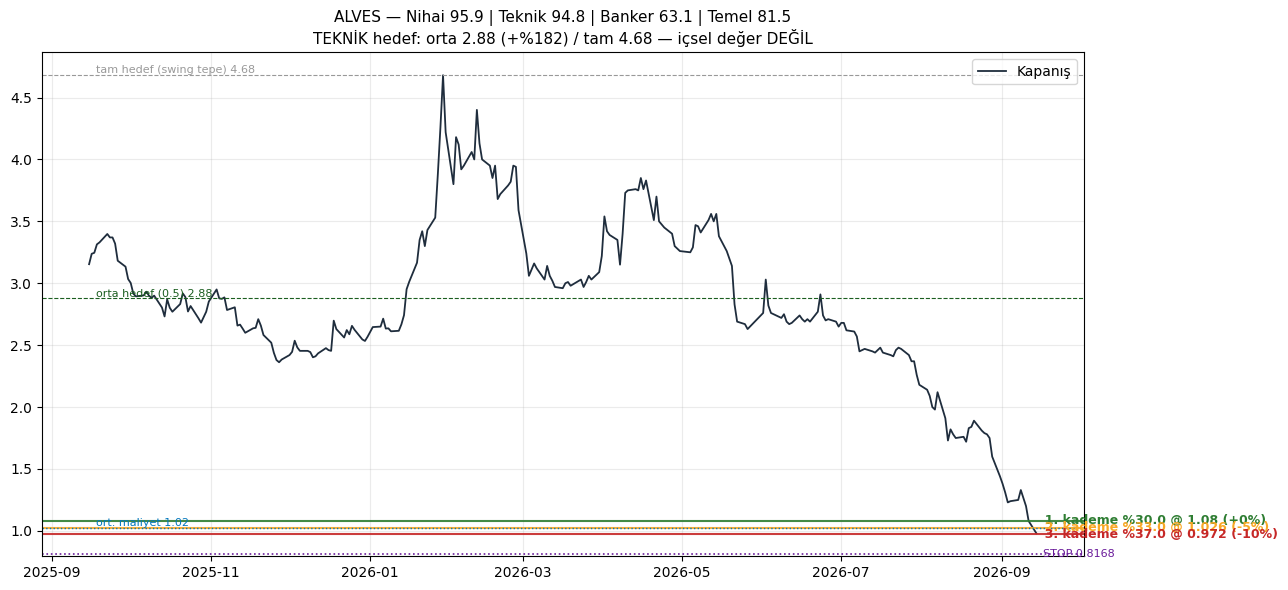

In [7]:
def plot_fib_ladder(symbol, results, n_bars=250):
    res = next((r for r in results if r.symbol == symbol), None)
    if res is None or res.ladder is None:
        print(f"{symbol}: sonuç/merdiven yok."); return
    df = load_daily_ohlcv(symbol, n_bars=600).tail(n_bars)
    L = res.ladder
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(df.index, df["close"], color="#1f2d3d", lw=1.3, label="Kapanış")
    _ws = sum(r["weight_pct"] for r in L.rungs) or 1
    _avg = sum(r["price"] * r["weight_pct"] for r in L.rungs) / _ws
    # Alım kademeleri (yeşil->sarı->kırmızı, güncelden yüzde ile)
    palette = ["#2e7d32", "#f9a825", "#c62828"]
    for i, rung in enumerate(L.rungs):
        c = palette[min(i, 2)]
        ax.axhline(rung["price"], color=c, lw=1.5, alpha=0.9)
        ax.text(df.index[-1], rung["price"],
                f"  {i+1}. kademe %{rung['weight_pct']} @ {rung['price']} ({rung.get('dip_pct',0):+.0f}%)",
                va="center", color=c, fontsize=9, fontweight="bold")
    # Ortalama maliyet + stop
    ax.axhline(_avg, color="#0277bd", ls=":", lw=1.0)
    ax.text(df.index[0], _avg, f"  ort. maliyet {_avg:.2f}", va="bottom", color="#0277bd", fontsize=8)
    ax.axhline(L.hard_stop, color="#6a1b9a", ls=":", lw=1.2)
    ax.text(df.index[-1], L.hard_stop, f"  STOP {L.hard_stop}", va="center", color="#6a1b9a", fontsize=8)
    # TEKNİK toparlanma hedefleri: orta (konservatif) ve tam (swing tepe)
    for lvl, lab, col in [(L.mid_recovery, "orta hedef (0.5)", "#1b5e20"),
                          (L.swing_high, "tam hedef (swing tepe)", "#999")]:
        if lvl:
            ax.axhline(lvl, color=col, ls="--", lw=0.8)
            ax.text(df.index[0], lvl, f"  {lab} {lvl}", va="bottom", color=col, fontsize=8)
    _go = (L.mid_recovery / _avg - 1) * 100 if L.mid_recovery else 0
    title = (f"{symbol} — Nihai {res.final_score} | Teknik {res.technical.total} | "
             f"Banker {res.banker.total} | Temel {res.fundamental.total}")
    title += (f"\nTEKNİK hedef: orta {L.mid_recovery} (+%{_go:.0f}) / tam {L.swing_high} — "
              f"içsel değer DEĞİL")
    ax.set_title(title, fontsize=11); ax.legend(loc="upper right"); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()

if not adaylar.empty:
    plot_fib_ladder(adaylar.iloc[0]["symbol"], results)   # kısa listenin 1. adayı

In [8]:
def alim_plani(symbol, results, sermaye=100_000):
    res = next((r for r in results if r.symbol == symbol), None)
    if res is None or res.ladder is None:
        print(f"{symbol}: merdiven yok."); return
    L = res.ladder
    print(f"=== {symbol} — Kademeli Alım Planı (sermaye {sermaye:,.0f} TL) ===")
    print(f"Nihai {res.final_score} | Teknik {res.technical.total} | Banker {res.banker.total} "
          f"| Temel {res.fundamental.total}")
    if res.trap.flags:
        print("⚠️  Tuzak:", "; ".join(res.trap.flags))
    print(f"Güncel {L.current_price} | swing {L.swing_low}–{L.swing_high}\n")
    for i, r in enumerate(L.rungs, 1):
        pay = sermaye * r["weight_pct"] / 100; lot = int(pay / r["price"])
        print(f"  {i}. kademe @ {r['price']:>8} ({r.get('dip_pct',0):+.0f}%)  "
              f"%{r['weight_pct']:<4} = {pay:>10,.0f} TL → ~{lot:,} lot  [{r['note']}]")
    _ws = sum(r["weight_pct"] for r in L.rungs) or 1
    _avg = sum(r["price"] * r["weight_pct"] for r in L.rungs) / _ws
    print(f"\n  Ort. maliyet {_avg:.2f} | STOP {L.hard_stop} ({(L.hard_stop/_avg-1)*100:+.0f}%)")
    print(f"  TEKNİK hedef: orta {L.mid_recovery} (+%{(L.mid_recovery/_avg-1)*100:.0f}) / "
          f"tam {L.swing_high} (+%{(L.swing_high/_avg-1)*100:.0f})  — grafik referansı, içsel değer DEĞİL")
    if L.dcf_target:
        print(f"  İÇSEL DEĞER ({res.intrinsic_method or '—'}): {L.dcf_target} → ort. maliyetten "
              f"+%{(L.dcf_target/_avg-1)*100:.0f}  (değerleme; güv. marjı {res.safety_margin*100:+.0f}%)")
    else:
        print(f"  İçsel değer: {res.intrinsic_method or 'veri yok'} — değerleme temel_skor kolonunda.")

if not adaylar.empty:
    alim_plani(adaylar.iloc[0]["symbol"], results)   # kısa listenin 1. adayı

=== ALVES — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 95.9 | Teknik 94.8 | Banker 63.1 | Temel 81.5
⚠️  Tuzak: DUSEN_BICAK (52h dibinde, dip teyidi yok)
Güncel 1.08 | swing 1.08–4.68

  1. kademe @     1.08 (+0%)  %30.0 =     30,000 TL → ~27,777 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    1.026 (-5%)  %33.0 =     33,000 TL → ~32,163 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    0.972 (-10%)  %37.0 =     37,000 TL → ~38,065 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 1.02 | STOP 0.8168 (-20%)
  TEKNİK hedef: orta 2.88 (+%182) / tam 4.68 (+%358)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 1.65 → ort. maliyetten +%61  (değerleme; güv. marjı +53%)


### 7b) Her aday için Fibonacci grafiği + kademeli alım planı (toplu)

Kısa listedeki **her aday** için ayrı grafik (Fibonacci kademeleri + stop + hedefler) ve
TL/lot bazlı kademeli alım planı üretir. `KAC_ADAY` ile kaç tanesi çizileceğini sınırlayın
(çok grafik notebook'u yavaşlatır).

### ALVES  [birikim+dip]
=== ALVES — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 95.9 | Teknik 94.8 | Banker 63.1 | Temel 81.5
⚠️  Tuzak: DUSEN_BICAK (52h dibinde, dip teyidi yok)
Güncel 1.08 | swing 1.08–4.68

  1. kademe @     1.08 (+0%)  %30.0 =     30,000 TL → ~27,777 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    1.026 (-5%)  %33.0 =     33,000 TL → ~32,163 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    0.972 (-10%)  %37.0 =     37,000 TL → ~38,065 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 1.02 | STOP 0.8168 (-20%)
  TEKNİK hedef: orta 2.88 (+%182) / tam 4.68 (+%358)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 1.65 → ort. maliyetten +%61  (değerleme; güv. marjı +53%)


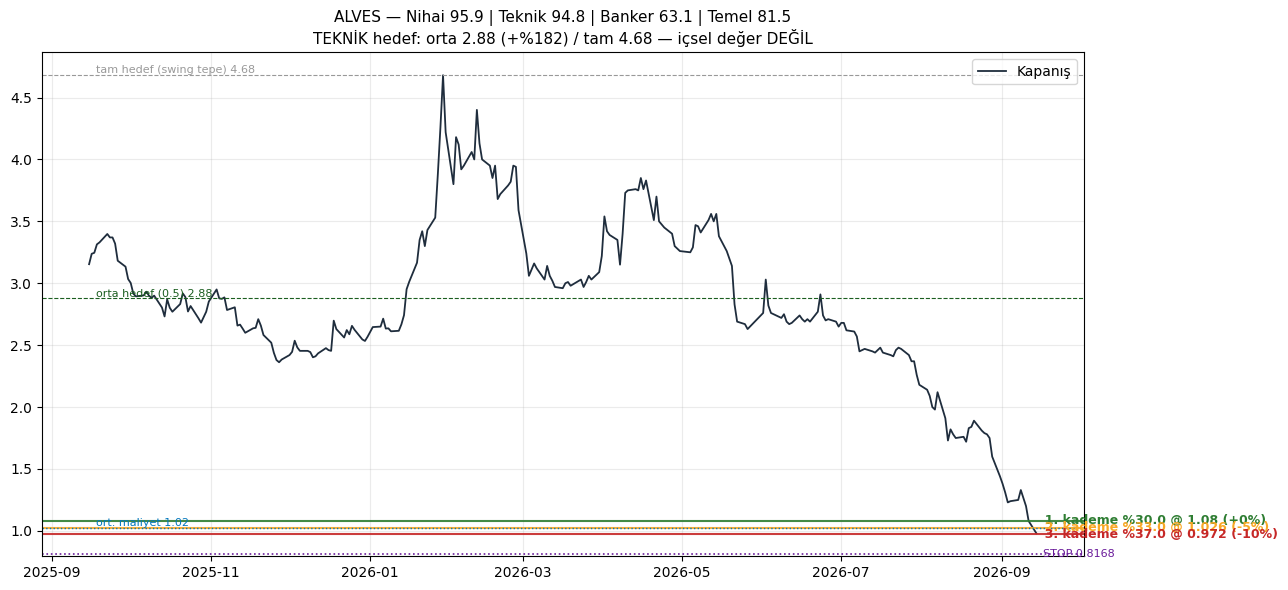

### EMKEL  [birikim+dip]
=== EMKEL — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 94.4 | Teknik 89.9 | Banker 66.3 | Temel 50.4
Güncel 12.94 | swing 12.65–62.1

  1. kademe @    12.94 (+0%)  %30.0 =     30,000 TL → ~2,318 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   12.293 (-5%)  %33.0 =     33,000 TL → ~2,684 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   11.646 (-10%)  %37.0 =     37,000 TL → ~3,177 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 12.25 | STOP 10.7344 (-12%)
  TEKNİK hedef: orta 37.375 (+%205) / tam 62.1 (+%407)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (FCF×8): 14.67 → ort. maliyetten +%20  (değerleme; güv. marjı +13%)


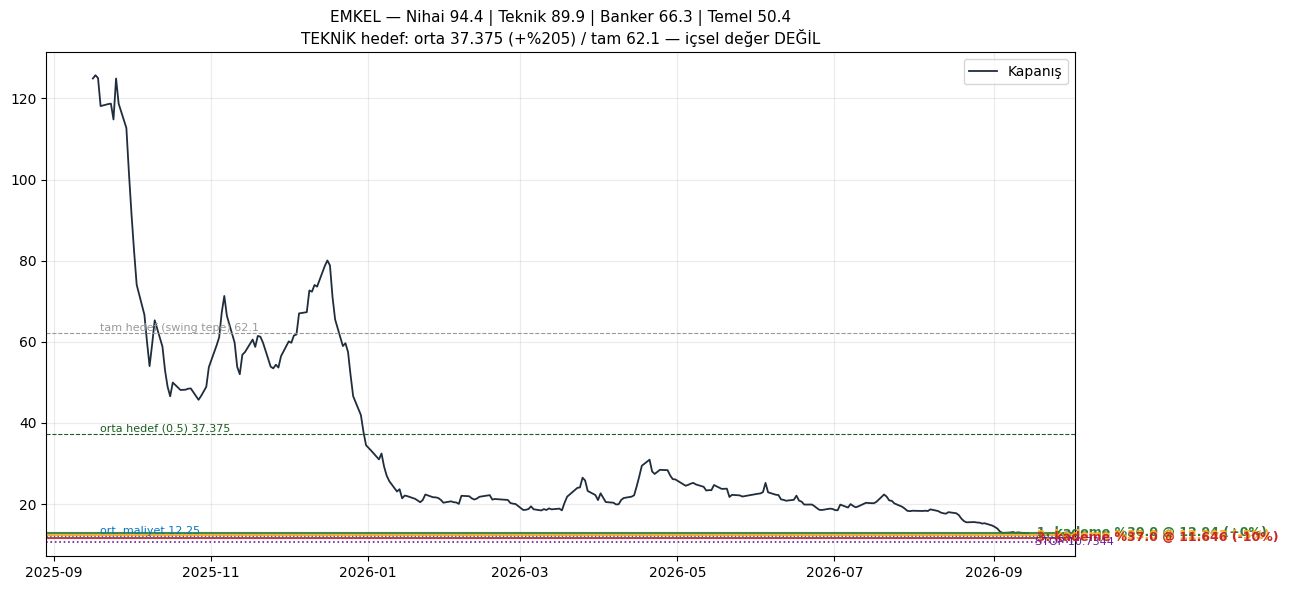

### KRSTL  [birikim+dip]
=== KRSTL — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 87.6 | Teknik 65.8 | Banker 66.5 | Temel 93.5
Güncel 8.76 | swing 7.93–12.5

  1. kademe @     8.76 (+0%)  %30.0 =     30,000 TL → ~3,424 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    8.345 (-5%)  %33.0 =     33,000 TL → ~3,954 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @     7.93 (-10%)  %37.0 =     37,000 TL → ~4,665 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 8.32 | STOP 7.6348 (-8%)
  TEKNİK hedef: orta 10.215 (+%23) / tam 12.5 (+%50)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 20.76 → ort. maliyetten +%150  (değerleme; güv. marjı +137%)


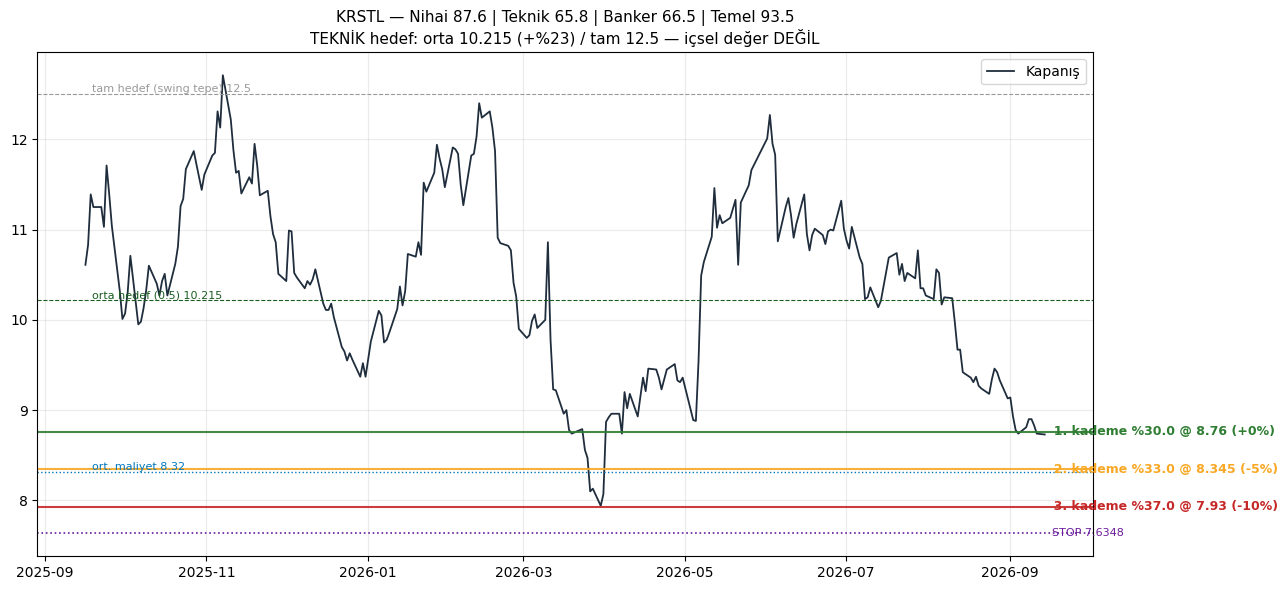

### RAYSG  [birikim+dip]
=== RAYSG — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 87.1 | Teknik 72.1 | Banker 62.7 | Temel 69.5
Güncel 152.9 | swing 149.8–255.5

  1. kademe @    152.9 (+0%)  %30.0 =     30,000 TL → ~196 lot  [1. kademe — güncel / hafif dip]
  2. kademe @  145.255 (-5%)  %33.0 =     33,000 TL → ~227 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   137.61 (-10%)  %37.0 =     37,000 TL → ~268 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 144.72 | STOP 130.546 (-10%)
  TEKNİK hedef: orta 202.65 (+%40) / tam 255.5 (+%77)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 177.28 → ort. maliyetten +%22  (değerleme; güv. marjı +16%)


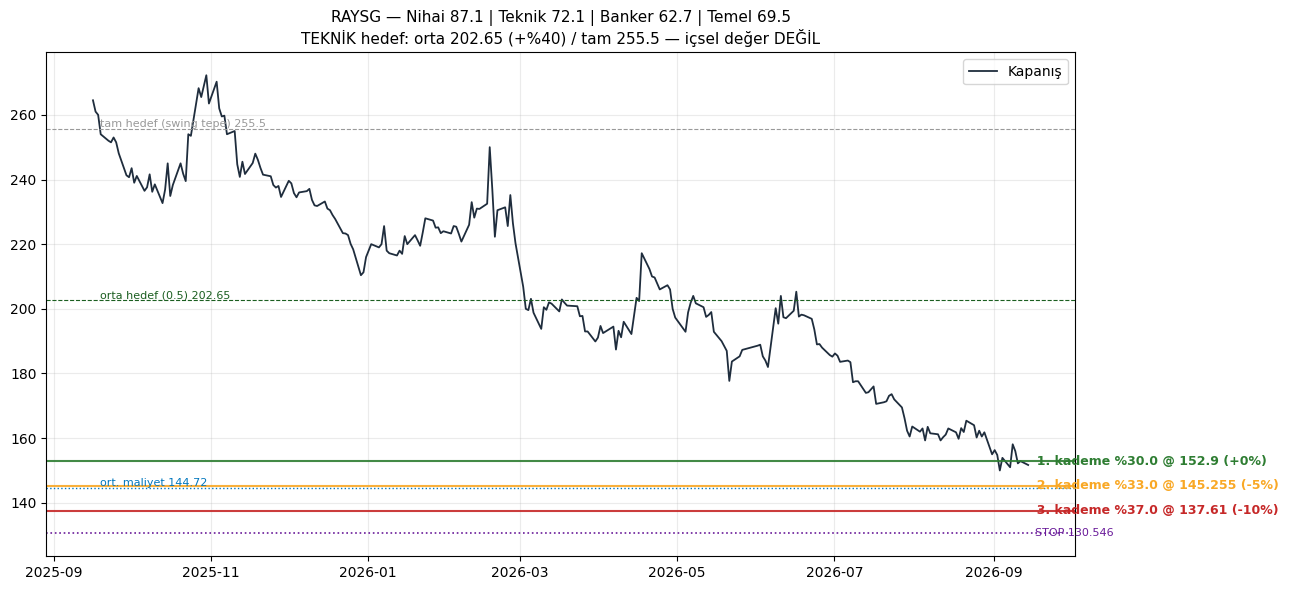

### TATEN  [birikim+dip]
=== TATEN — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 83.0 | Teknik 82.5 | Banker 47.9 | Temel 34.3
Güncel 7.61 | swing 7.41–21.2

  1. kademe @     7.61 (+0%)  %30.0 =     30,000 TL → ~3,942 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   7.2295 (-5%)  %33.0 =     33,000 TL → ~4,564 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    6.849 (-10%)  %37.0 =     37,000 TL → ~5,402 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 7.20 | STOP 6.1081 (-15%)
  TEKNİK hedef: orta 14.305 (+%99) / tam 21.2 (+%194)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: veri yok — değerleme temel_skor kolonunda.


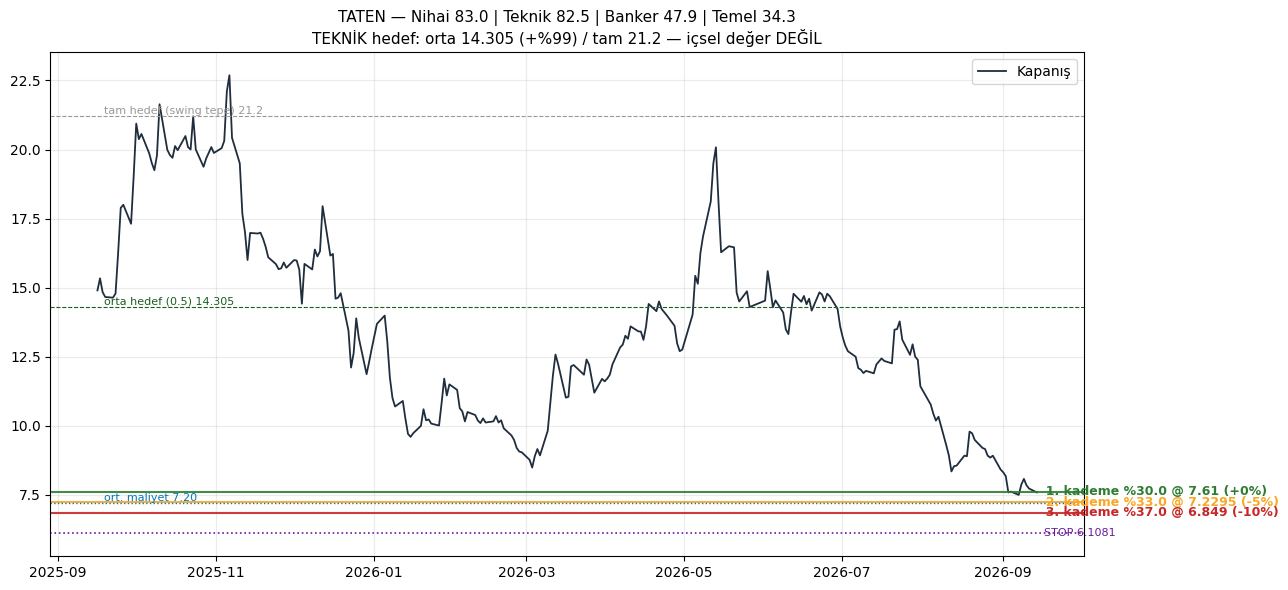

### TUREX  [birikim+dip]
=== TUREX — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 82.1 | Teknik 74.3 | Banker 60.0 | Temel 68.1
Güncel 5.96 | swing 5.87–9.99

  1. kademe @     5.96 (+0%)  %30.0 =     30,000 TL → ~5,033 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    5.662 (-5%)  %33.0 =     33,000 TL → ~5,828 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    5.364 (-10%)  %37.0 =     37,000 TL → ~6,897 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 5.64 | STOP 5.0757 (-10%)
  TEKNİK hedef: orta 7.93 (+%41) / tam 9.99 (+%77)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: şüpheli — değerleme temel_skor kolonunda.


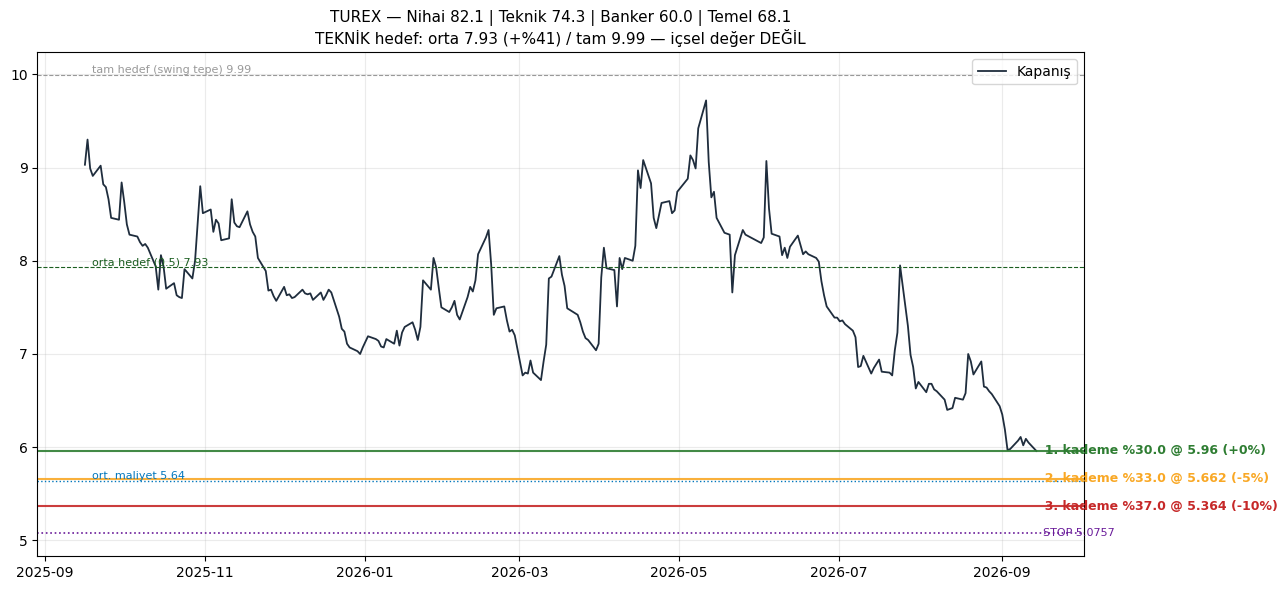

### BALSU  [birikim+dip]
=== BALSU — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 80.3 | Teknik 78.5 | Banker 62.1 | Temel 46.8
Güncel 8.73 | swing 7.82–21.42

  1. kademe @     8.73 (+0%)  %30.0 =     30,000 TL → ~3,436 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    8.275 (-5%)  %33.0 =     33,000 TL → ~3,987 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @     7.82 (-10%)  %37.0 =     37,000 TL → ~4,731 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 8.24 | STOP 6.6429 (-19%)
  TEKNİK hedef: orta 14.62 (+%77) / tam 21.42 (+%160)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 9.72 → ort. maliyetten +%18  (değerleme; güv. marjı +11%)


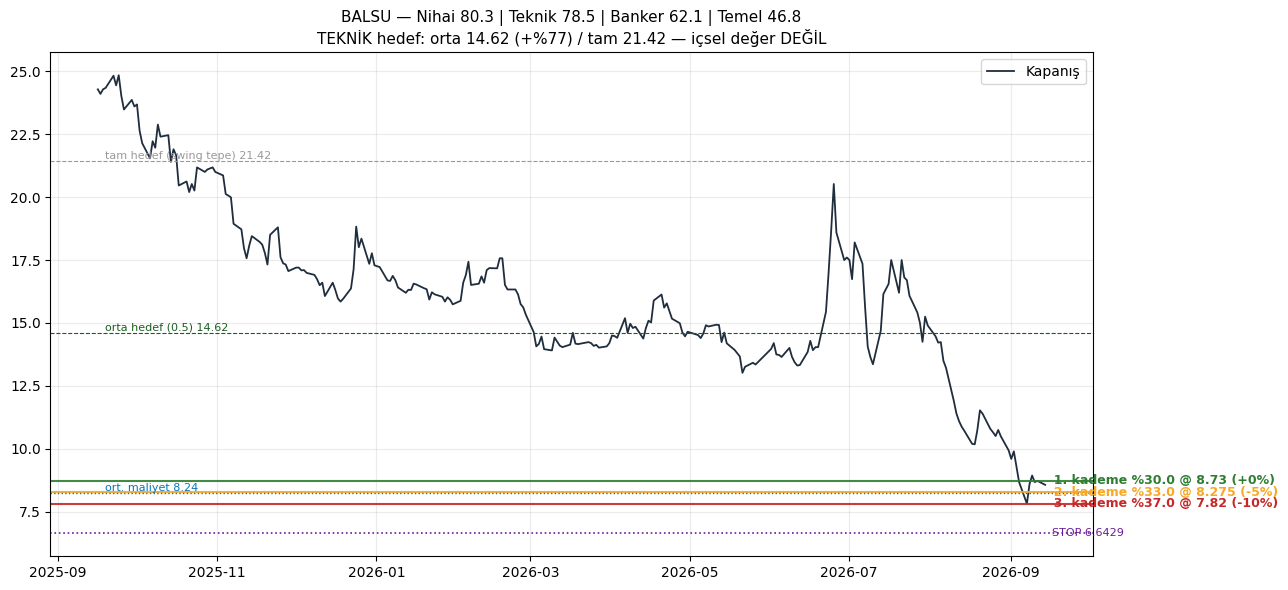

### HDFGS  [birikim]
=== HDFGS — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 78.5 | Teknik 82.8 | Banker 61.7 | Temel 86.3
⚠️  Tuzak: DUSEN_BICAK (52h dibinde, dip teyidi yok)
Güncel 2.26 | swing 2.23–4.2

  1. kademe @     2.26 (+0%)  %30.0 =     30,000 TL → ~13,274 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    2.147 (-5%)  %33.0 =     33,000 TL → ~15,370 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    2.034 (-10%)  %37.0 =     37,000 TL → ~18,190 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 2.14 | STOP 1.8802 (-12%)
  TEKNİK hedef: orta 3.215 (+%50) / tam 4.2 (+%96)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: şüpheli — değerleme temel_skor kolonunda.


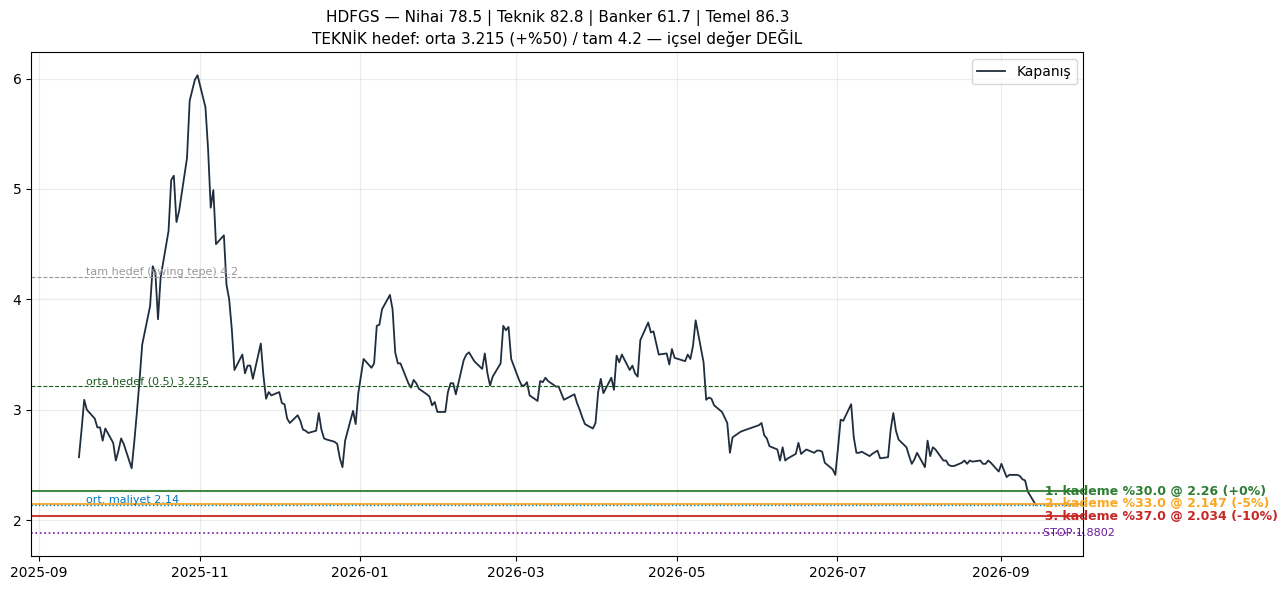

### VAKFN  [birikim+dip]
=== VAKFN — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 75.4 | Teknik 73.9 | Banker 66.6 | Temel 81.4
⚠️  Tuzak: DUSEN_BICAK (52h dibinde, dip teyidi yok)
Güncel 1.13 | swing 1.11–1.95

  1. kademe @     1.13 (+0%)  %30.0 =     30,000 TL → ~26,548 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   1.0735 (-5%)  %33.0 =     33,000 TL → ~30,740 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    1.017 (-10%)  %37.0 =     37,000 TL → ~36,381 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 1.07 | STOP 0.969 (-9%)
  TEKNİK hedef: orta 1.53 (+%43) / tam 1.95 (+%82)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 3.07 → ort. maliyetten +%187  (değerleme; güv. marjı +172%)


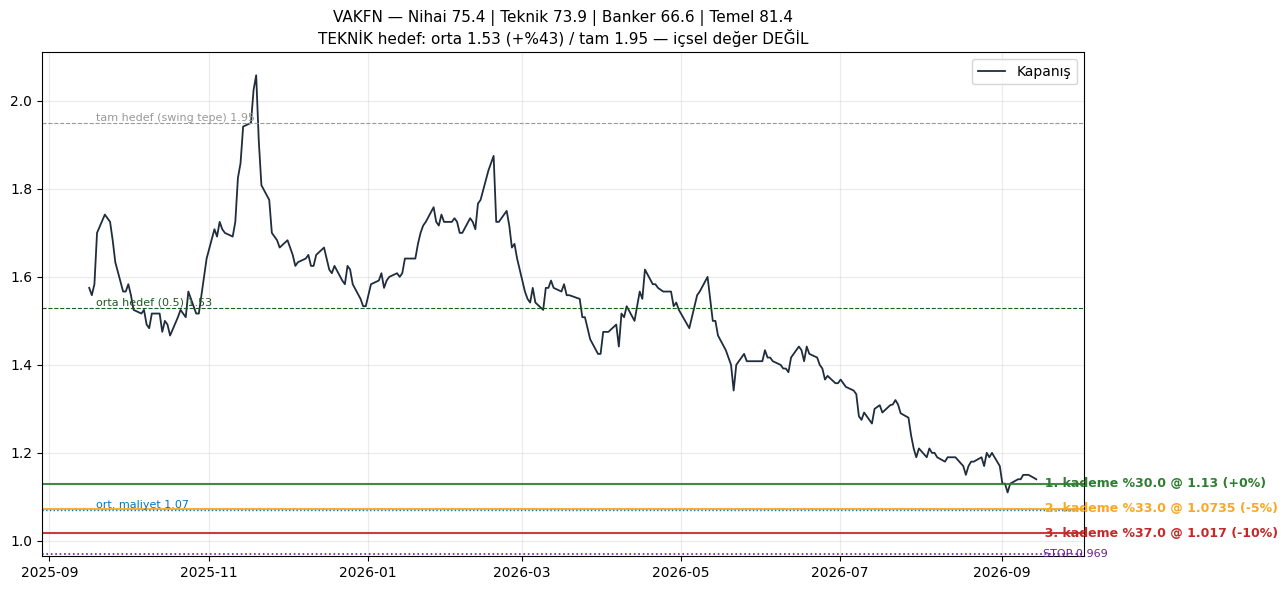

### MOPAS  [birikim+dip]
=== MOPAS — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 75.2 | Teknik 84.7 | Banker 64.3 | Temel 46.3
⚠️  Tuzak: DUSEN_BICAK (52h dibinde, dip teyidi yok)
Güncel 25.28 | swing 24.88–64.15

  1. kademe @    25.28 (+0%)  %30.0 =     30,000 TL → ~1,186 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   24.016 (-5%)  %33.0 =     33,000 TL → ~1,374 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   22.752 (-10%)  %37.0 =     37,000 TL → ~1,626 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 23.93 | STOP 21.5147 (-10%)
  TEKNİK hedef: orta 44.515 (+%86) / tam 64.15 (+%168)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 23.5 → ort. maliyetten +%-2  (değerleme; güv. marjı -7%)


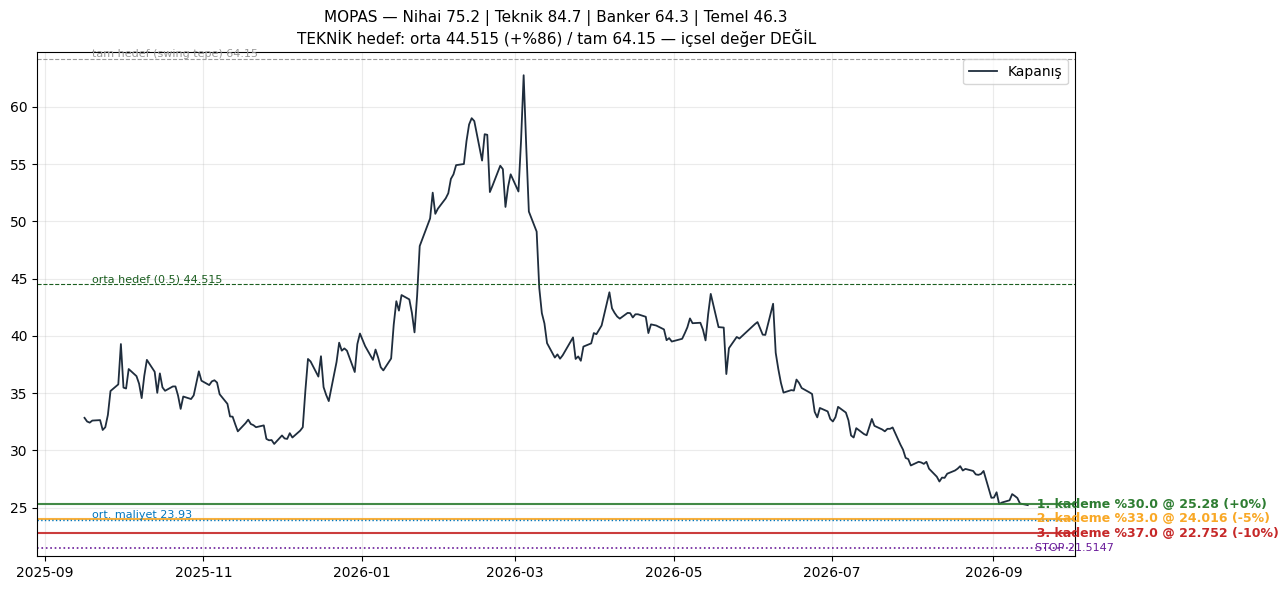

### OSMEN  [birikim+dip]
=== OSMEN — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 74.4 | Teknik 62.7 | Banker 61.9 | Temel 86.4
Güncel 6.95 | swing 6.77–10.09

  1. kademe @     6.95 (+0%)  %30.0 =     30,000 TL → ~4,316 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   6.6025 (-5%)  %33.0 =     33,000 TL → ~4,998 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    6.255 (-10%)  %37.0 =     37,000 TL → ~5,915 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 6.58 | STOP 5.8284 (-11%)
  TEKNİK hedef: orta 8.43 (+%28) / tam 10.09 (+%53)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 12.29 → ort. maliyetten +%87  (değerleme; güv. marjı +77%)


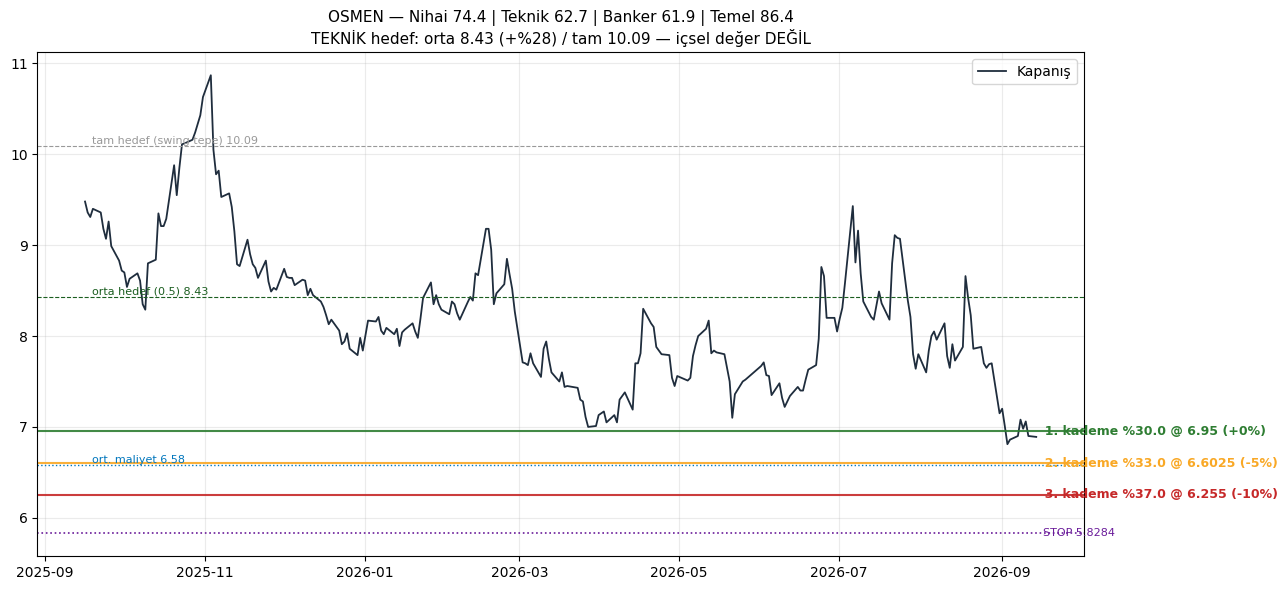

### YUNSA  [birikim]
=== YUNSA — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 72.3 | Teknik 59.1 | Banker 75.8 | Temel 83.7
Güncel 7.59 | swing 7.22–11.2

  1. kademe @     7.59 (+0%)  %30.0 =     30,000 TL → ~3,952 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   7.2105 (-5%)  %33.0 =     33,000 TL → ~4,576 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    6.831 (-10%)  %37.0 =     37,000 TL → ~5,416 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 7.18 | STOP 6.4855 (-10%)
  TEKNİK hedef: orta 9.21 (+%28) / tam 11.2 (+%56)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 13.19 → ort. maliyetten +%84  (değerleme; güv. marjı +74%)


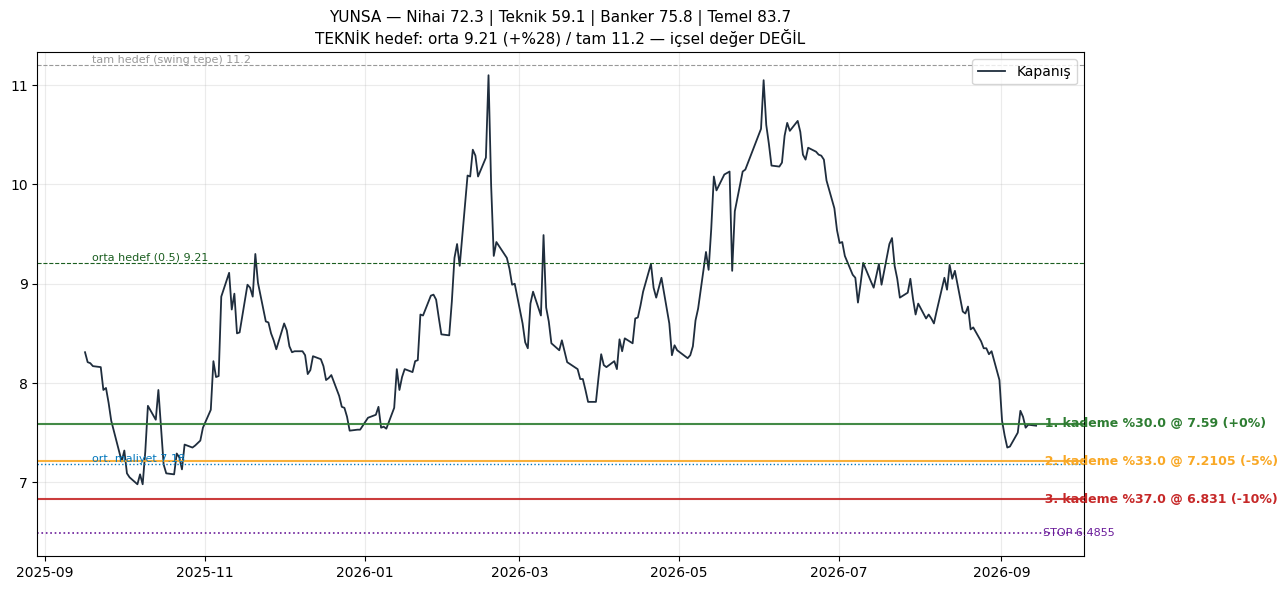

### MAKIM  [birikim+dip]
=== MAKIM — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 67.6 | Teknik 65.2 | Banker 58.6 | Temel 52.6
Güncel 14.6 | swing 14.22–20.9

  1. kademe @     14.6 (+0%)  %30.0 =     30,000 TL → ~2,054 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    13.87 (-5%)  %33.0 =     33,000 TL → ~2,379 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    13.14 (-10%)  %37.0 =     37,000 TL → ~2,815 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 13.82 | STOP 12.3652 (-11%)
  TEKNİK hedef: orta 17.56 (+%27) / tam 20.9 (+%51)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 15.28 → ort. maliyetten +%11  (değerleme; güv. marjı +5%)


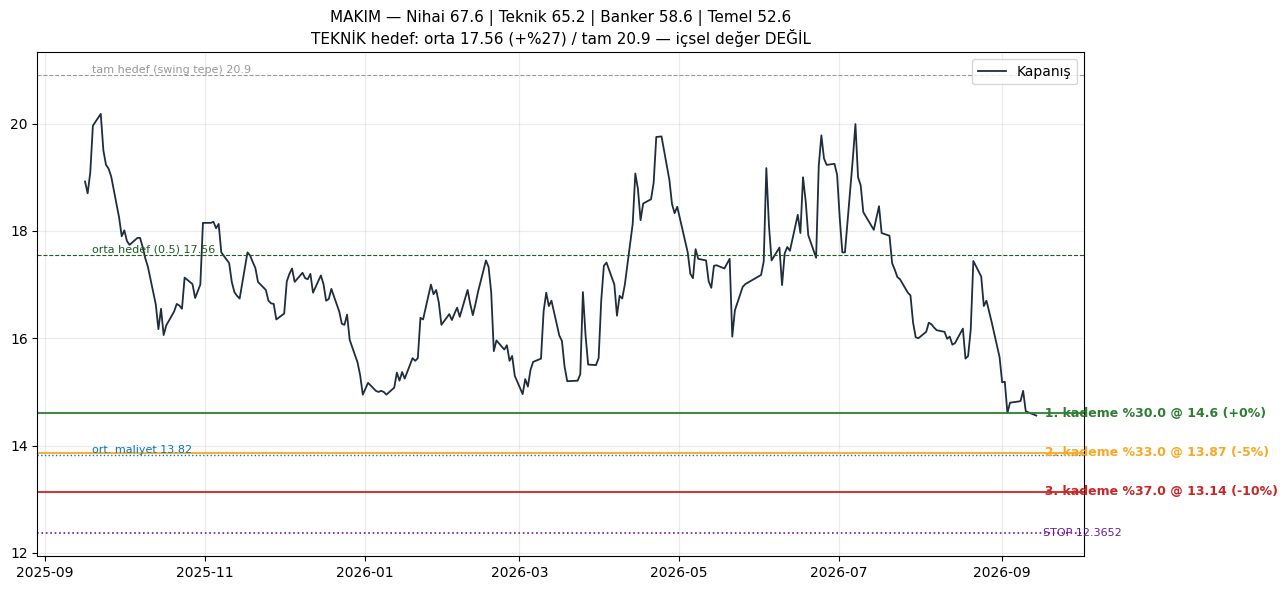

### TEKTU  [birikim+dip]
=== TEKTU — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 66.5 | Teknik 74.8 | Banker 59.6 | Temel 0.0
Güncel 7.26 | swing 7.07–14.63

  1. kademe @     7.26 (+0%)  %30.0 =     30,000 TL → ~4,132 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    6.897 (-5%)  %33.0 =     33,000 TL → ~4,784 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    6.534 (-10%)  %37.0 =     37,000 TL → ~5,662 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 6.87 | STOP 5.9863 (-13%)
  TEKNİK hedef: orta 10.85 (+%58) / tam 14.63 (+%113)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: şüpheli — değerleme temel_skor kolonunda.


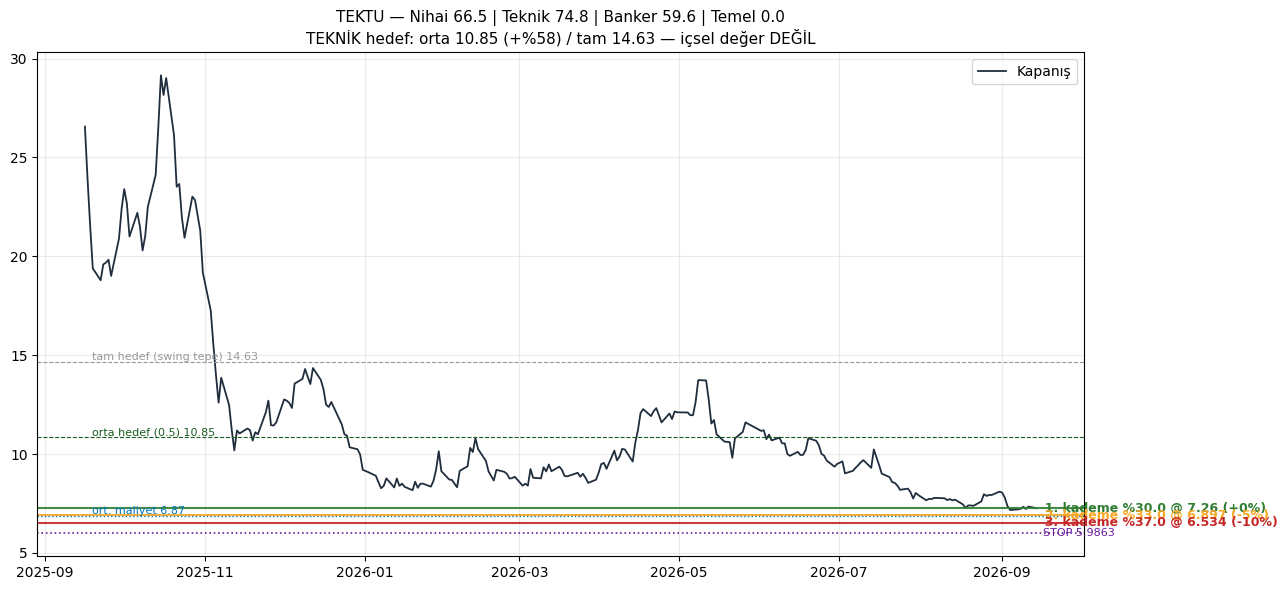

### EGEGY  [birikim]
=== EGEGY — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 64.4 | Teknik 54.4 | Banker 59.0 | Temel 88.3
Güncel 25.36 | swing 22.2–35.48

  1. kademe @    25.36 (+0%)  %30.0 =     30,000 TL → ~1,182 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    23.78 (-6%)  %33.0 =     33,000 TL → ~1,387 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @     22.2 (-12%)  %37.0 =     37,000 TL → ~1,666 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 23.67 | STOP 19.657 (-17%)
  TEKNİK hedef: orta 28.84 (+%22) / tam 35.48 (+%50)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 40.94 → ort. maliyetten +%73  (değerleme; güv. marjı +61%)


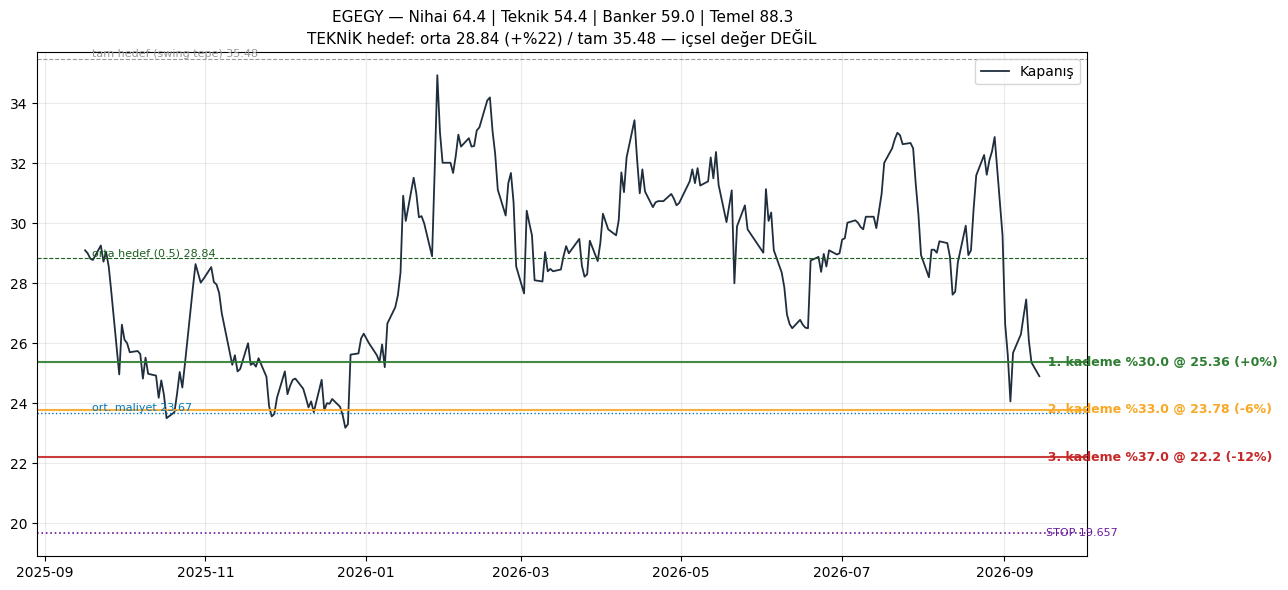

### IHLGM  [birikim]
=== IHLGM — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 63.1 | Teknik 51.9 | Banker 57.9 | Temel 96.8
Güncel 1.65 | swing 1.51–2.48

  1. kademe @     1.65 (+0%)  %30.0 =     30,000 TL → ~18,181 lot  [1. kademe — güncel / hafif dip]
  2. kademe @     1.58 (-4%)  %33.0 =     33,000 TL → ~20,886 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @     1.51 (-8%)  %37.0 =     37,000 TL → ~24,503 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 1.58 | STOP 1.4336 (-9%)
  TEKNİK hedef: orta 1.995 (+%27) / tam 2.48 (+%57)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: şüpheli — değerleme temel_skor kolonunda.


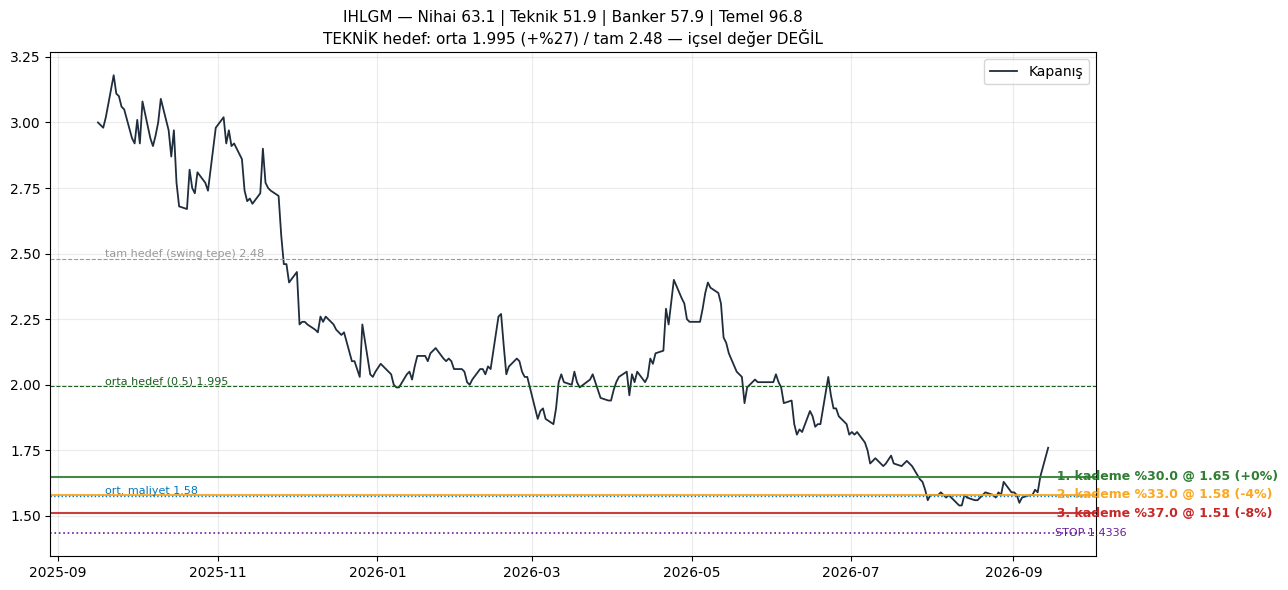

### GEDIK  [birikim]
=== GEDIK — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 62.8 | Teknik 59.8 | Banker 67.2 | Temel 49.8
Güncel 5.65 | swing 4.95–8.05

  1. kademe @     5.65 (+0%)  %30.0 =     30,000 TL → ~5,309 lot  [1. kademe — güncel / hafif dip]
  2. kademe @      5.3 (-6%)  %33.0 =     33,000 TL → ~6,226 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @     4.95 (-12%)  %37.0 =     37,000 TL → ~7,474 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 5.28 | STOP 4.6408 (-12%)
  TEKNİK hedef: orta 6.5 (+%23) / tam 8.05 (+%53)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 6.05 → ort. maliyetten +%15  (değerleme; güv. marjı +7%)


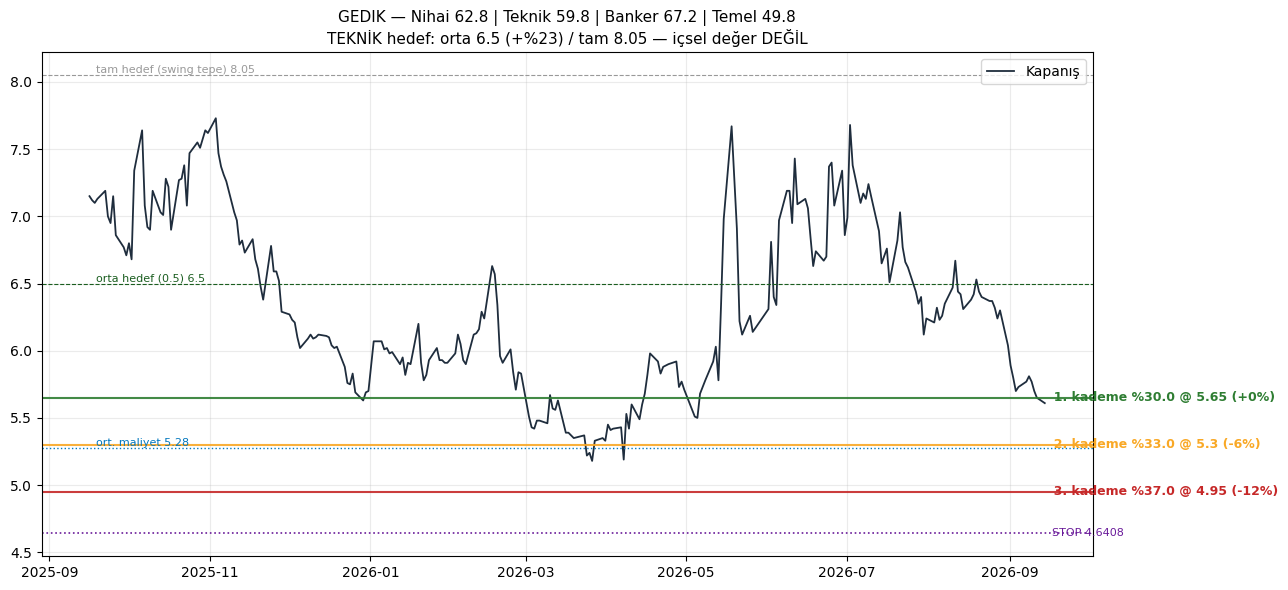

### KATMR  [birikim+dip]
=== KATMR — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 61.9 | Teknik 82.1 | Banker 69.7 | Temel 37.2
⚠️  Tuzak: EV/EBITDA_PAHALI (isletme degeri yuksek)
Güncel 1.88 | swing 1.81–3.39

  1. kademe @     1.88 (+0%)  %30.0 =     30,000 TL → ~15,957 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    1.786 (-5%)  %33.0 =     33,000 TL → ~18,477 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    1.692 (-10%)  %37.0 =     37,000 TL → ~21,867 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 1.78 | STOP 1.5961 (-10%)
  TEKNİK hedef: orta 2.6 (+%46) / tam 3.39 (+%91)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 1.81 → ort. maliyetten +%2  (değerleme; güv. marjı -4%)


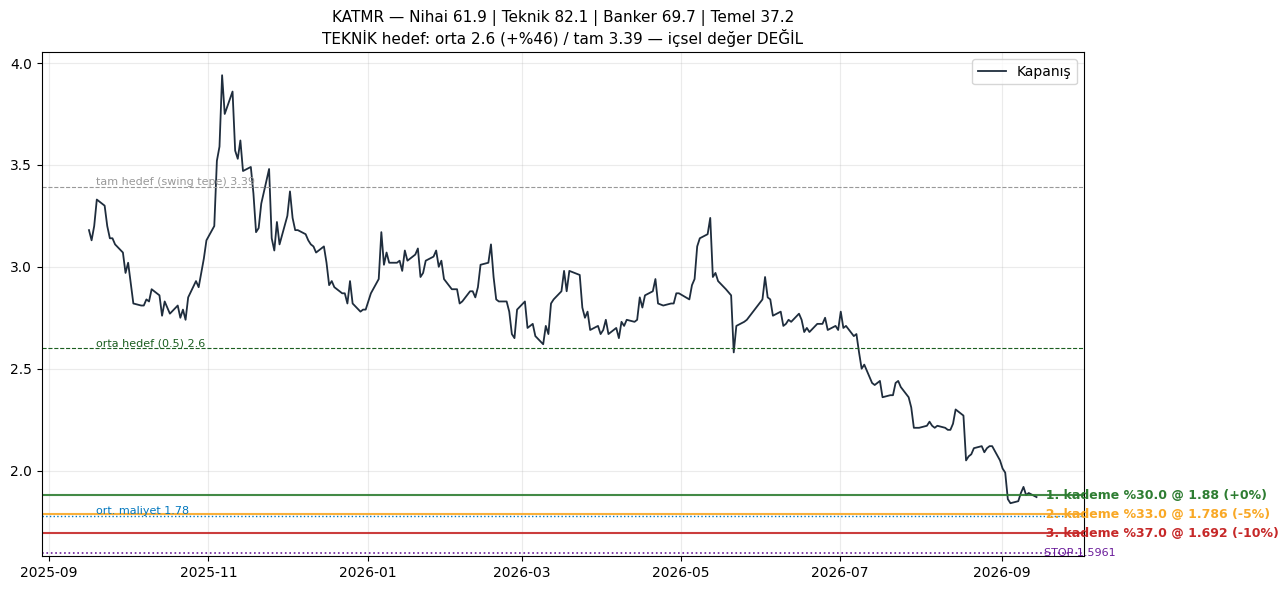

### KAPLM  [birikim+dip]
=== KAPLM — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 61.5 | Teknik 67.2 | Banker 71.5 | Temel 14.9
Güncel 368.25 | swing 267.0–746.5

  1. kademe @   368.25 (+0%)  %30.0 =     30,000 TL → ~81 lot  [1. kademe — güncel / hafif dip]
  2. kademe @ 327.7425 (-11%)  %33.0 =     33,000 TL → ~100 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @  287.235 (-22%)  %37.0 =     37,000 TL → ~128 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 324.91 | STOP 259.4923 (-20%)
  TEKNİK hedef: orta 506.75 (+%56) / tam 746.5 (+%130)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: veri yok — değerleme temel_skor kolonunda.


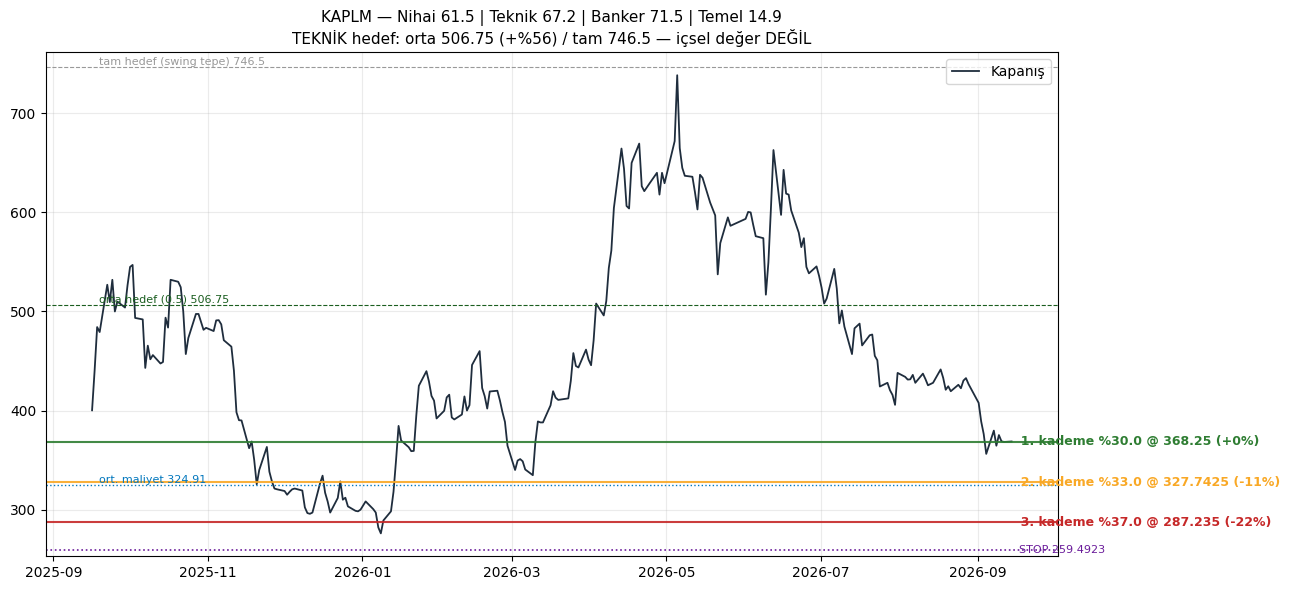

### AVHOL  [birikim]
=== AVHOL — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 58.2 | Teknik 54.7 | Banker 72.6 | Temel 49.1
Güncel 34.68 | swing 32.74–54.5

  1. kademe @    34.68 (+0%)  %30.0 =     30,000 TL → ~865 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   32.946 (-5%)  %33.0 =     33,000 TL → ~1,001 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   31.212 (-10%)  %37.0 =     37,000 TL → ~1,185 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 32.82 | STOP 29.4994 (-10%)
  TEKNİK hedef: orta 43.62 (+%33) / tam 54.5 (+%66)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: veri yok — değerleme temel_skor kolonunda.


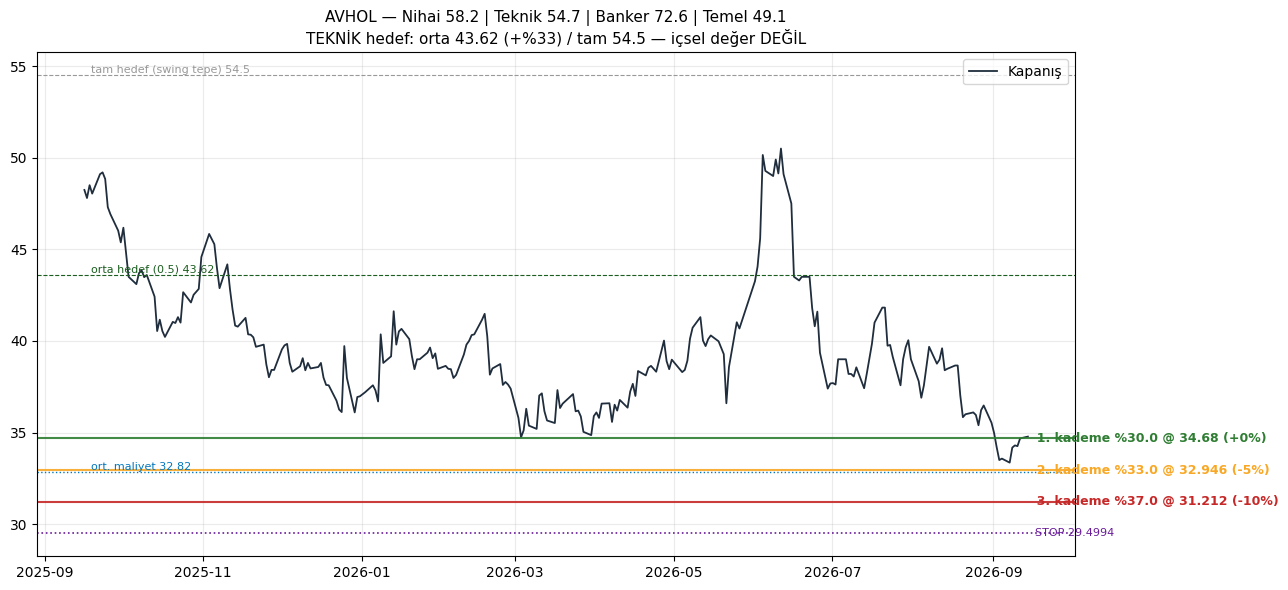

### NTHOL  [birikim]
=== NTHOL — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 57.8 | Teknik 50.0 | Banker 59.8 | Temel 80.8
Güncel 41.18 | swing 35.12–54.2

  1. kademe @    41.18 (+0%)  %30.0 =     30,000 TL → ~728 lot  [1. kademe — güncel / hafif dip]
  2. kademe @    38.15 (-7%)  %33.0 =     33,000 TL → ~865 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @    35.12 (-15%)  %37.0 =     37,000 TL → ~1,053 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 37.94 | STOP 33.3007 (-12%)
  TEKNİK hedef: orta 44.66 (+%18) / tam 54.2 (+%43)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (Graham): 85.96 → ort. maliyetten +%127  (değerleme; güv. marjı +109%)


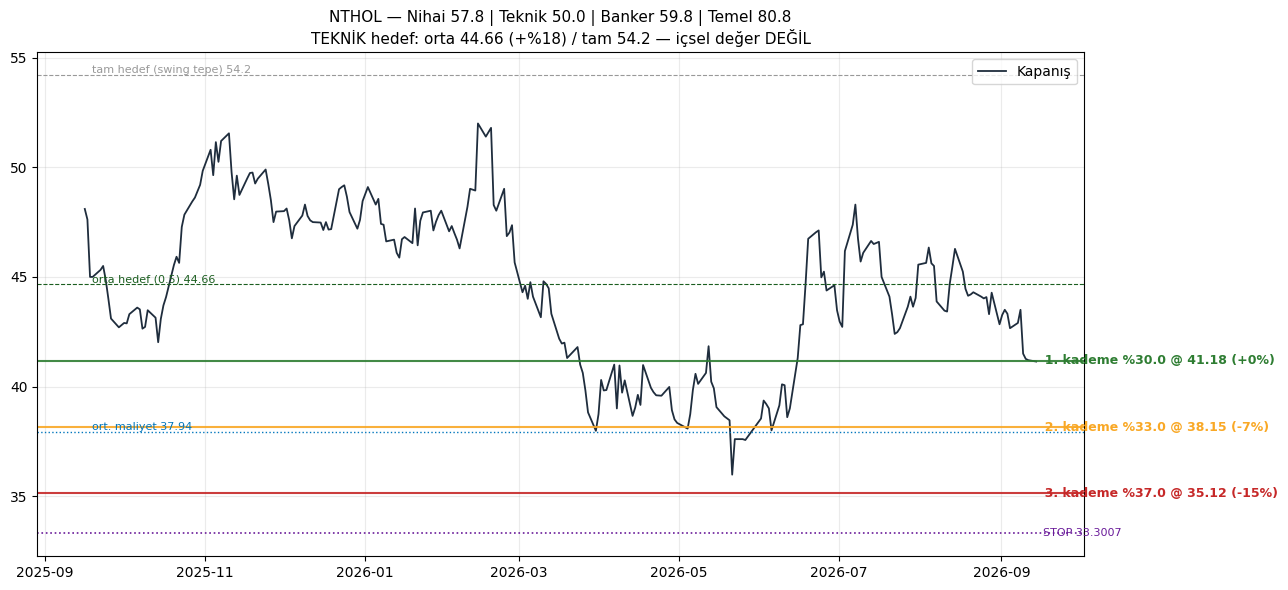

### BEYAZ  [birikim]
=== BEYAZ — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 57.7 | Teknik 52.2 | Banker 82.2 | Temel 52.2
Güncel 22.96 | swing 21.3–37.58

  1. kademe @    22.96 (+0%)  %30.0 =     30,000 TL → ~1,306 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   21.812 (-5%)  %33.0 =     33,000 TL → ~1,512 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   20.664 (-10%)  %37.0 =     37,000 TL → ~1,790 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 21.73 | STOP 19.3469 (-11%)
  TEKNİK hedef: orta 29.44 (+%35) / tam 37.58 (+%73)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: veri yok — değerleme temel_skor kolonunda.


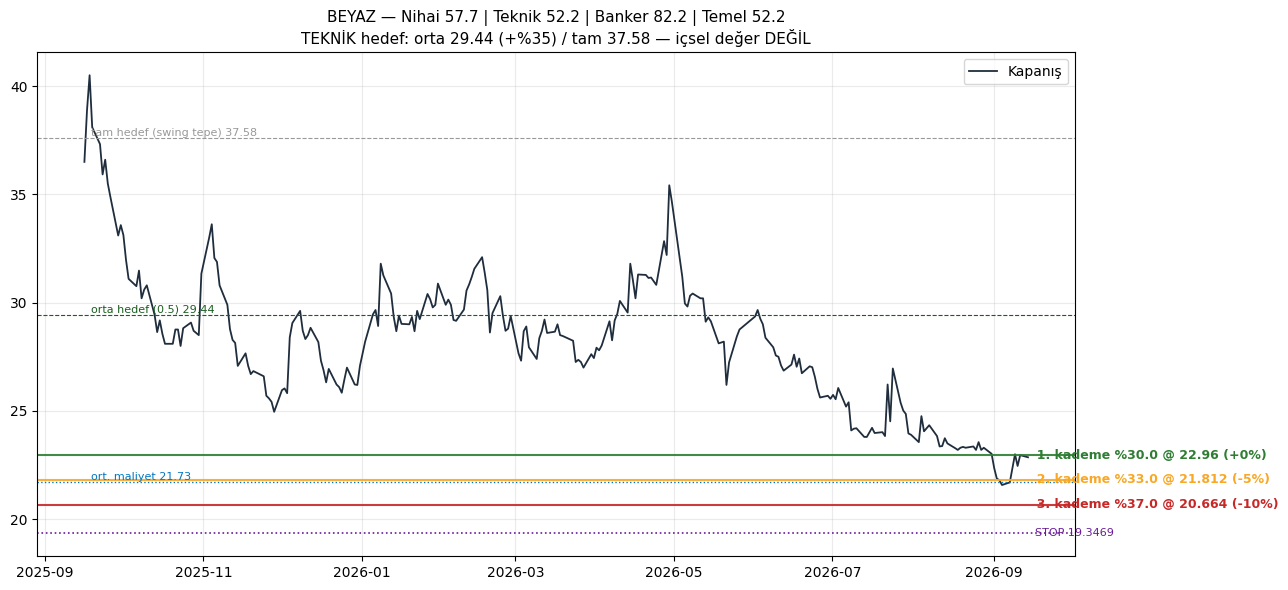

### MEYSU  [birikim]
=== MEYSU — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 57.6 | Teknik 54.5 | Banker 61.2 | Temel 55.8
Güncel 11.16 | swing 8.25–22.82

  1. kademe @    11.16 (+0%)  %30.0 =     30,000 TL → ~2,688 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   9.9324 (-11%)  %33.0 =     33,000 TL → ~3,322 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   8.7048 (-22%)  %37.0 =     37,000 TL → ~4,250 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 9.85 | STOP 7.8511 (-20%)
  TEKNİK hedef: orta 15.535 (+%58) / tam 22.82 (+%132)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: veri yok — değerleme temel_skor kolonunda.


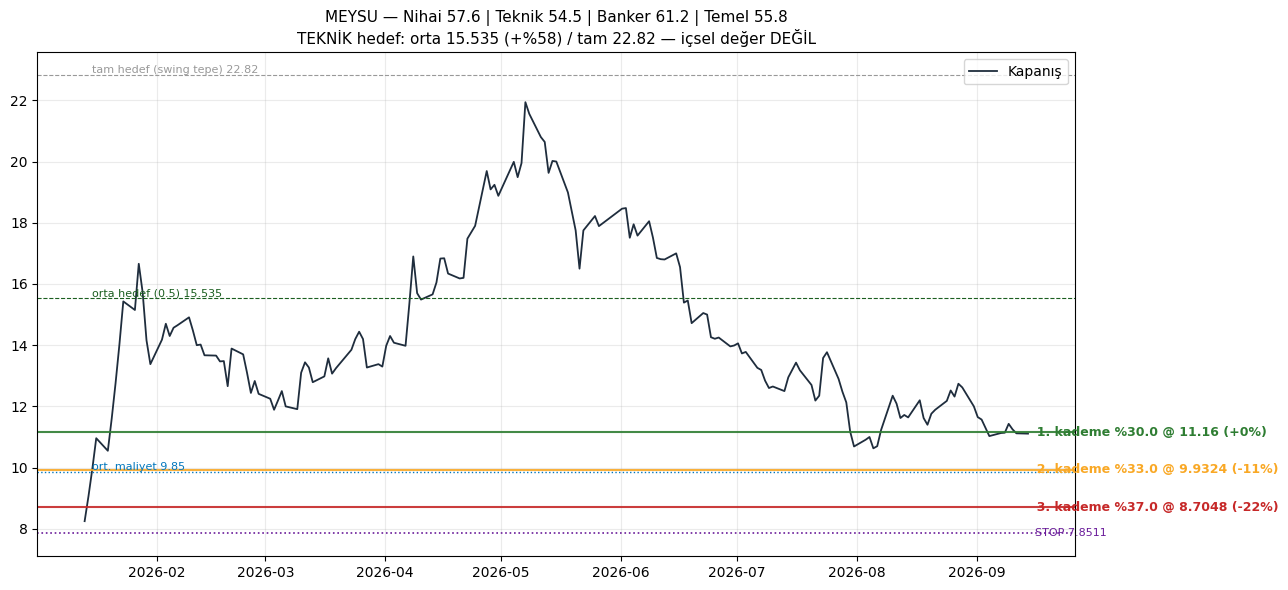

### DGNMO  [birikim]
=== DGNMO — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 56.4 | Teknik 51.0 | Banker 60.9 | Temel 67.6
Güncel 6.88 | swing 3.45–10.68

  1. kademe @     6.88 (+0%)  %30.0 =     30,000 TL → ~4,360 lot  [1. kademe — güncel / hafif dip]
  2. kademe @   6.1232 (-11%)  %33.0 =     33,000 TL → ~5,389 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   5.3664 (-22%)  %37.0 =     37,000 TL → ~6,894 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 6.07 | STOP 4.6784 (-23%)
  TEKNİK hedef: orta 7.065 (+%16) / tam 10.68 (+%76)  — grafik referansı, içsel değer DEĞİL
  İÇSEL DEĞER (FCF×8): 11.64 → ort. maliyetten +%92  (değerleme; güv. marjı +69%)


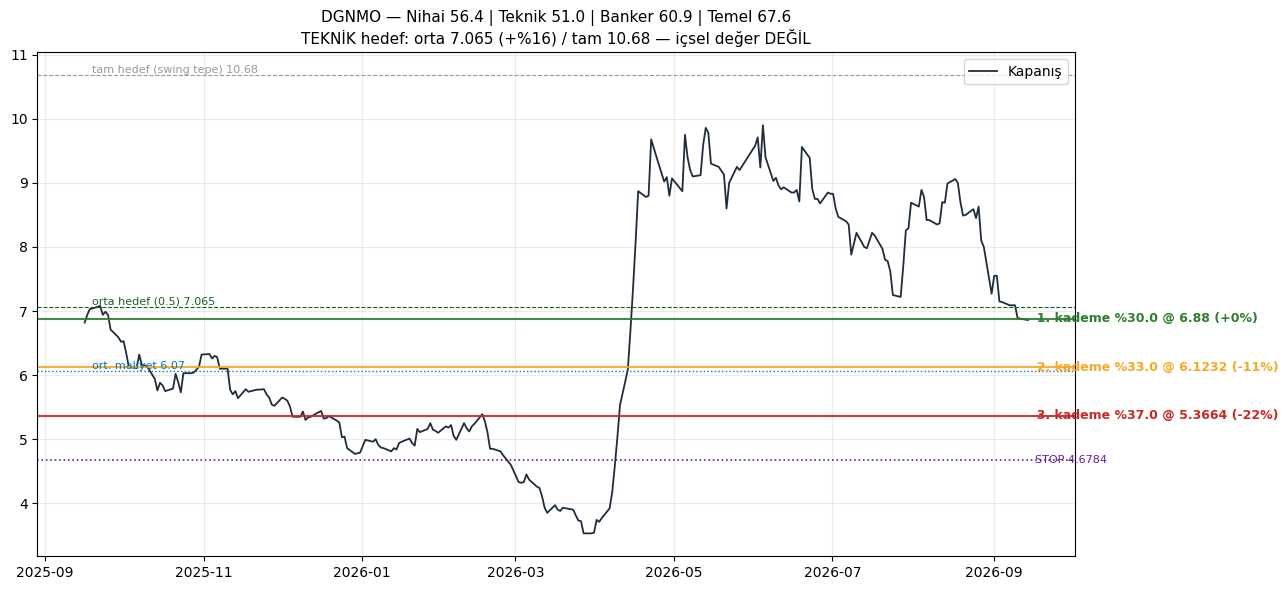

### TKNSA  [birikim+dip]
=== TKNSA — Kademeli Alım Planı (sermaye 100,000 TL) ===
Nihai 55.8 | Teknik 66.9 | Banker 64.1 | Temel 0.0
Güncel 16.59 | swing 15.71–27.5

  1. kademe @    16.59 (+0%)  %30.0 =     30,000 TL → ~1,808 lot  [1. kademe — güncel / hafif dip]
  2. kademe @  15.7605 (-5%)  %33.0 =     33,000 TL → ~2,093 lot  [2. kademe — orta dip (0.5 Fib)]
  3. kademe @   14.931 (-10%)  %37.0 =     37,000 TL → ~2,478 lot  [3. kademe — band tabanı (swing dip / kapitülasyon)]

  Ort. maliyet 15.70 | STOP 13.5723 (-14%)
  TEKNİK hedef: orta 21.605 (+%38) / tam 27.5 (+%75)  — grafik referansı, içsel değer DEĞİL
  İçsel değer: veri yok — değerleme temel_skor kolonunda.


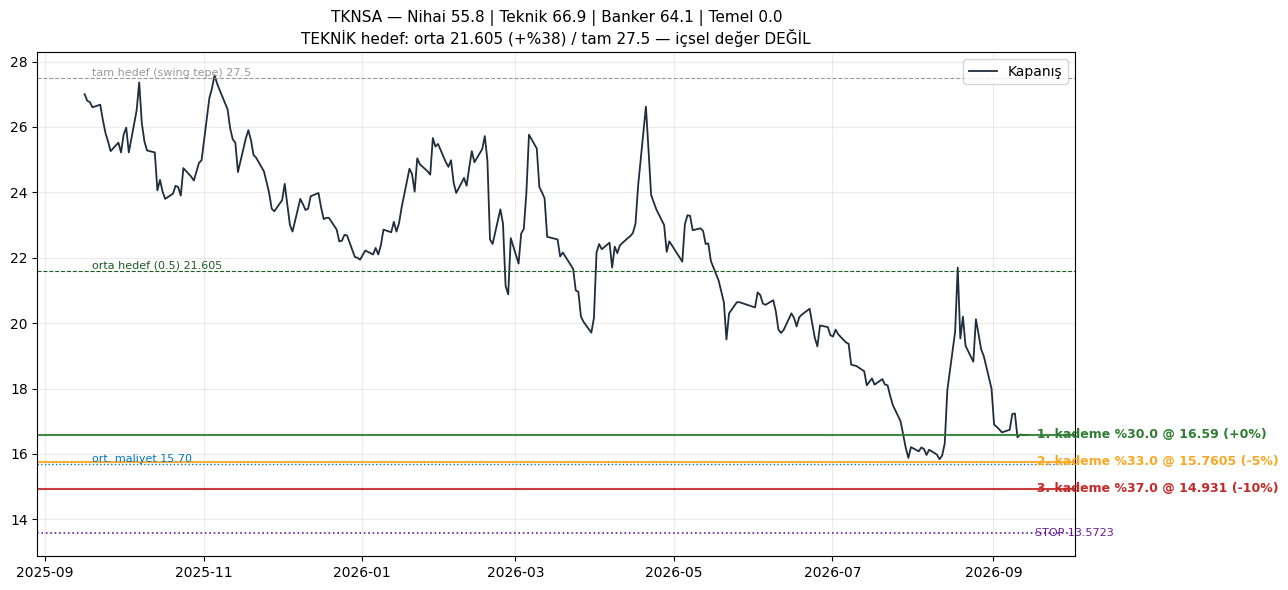

In [9]:
# Varsayılan: TÜM adaylar için plan+grafik (adayların alım planı gözardı edilmesin).
# Çok grafik notebook'u yavaşlatırsa bu sayıyı düşür (ör. KAC_ADAY = 8).
KAC_ADAY = len(adaylar)
_sermaye = globals().get("SERMAYE", 100_000)
for _sym in adaylar["symbol"].head(KAC_ADAY):
    _tip = adaylar.loc[adaylar["symbol"]==_sym, "tip"].iloc[0]
    print("=" * 74)
    print(f"### {_sym}  [{_tip}]")
    alim_plani(_sym, results, sermaye=_sermaye)
    plot_fib_ladder(_sym, results)

> ⚠️ **İki AYRI hedef — karıştırmayın.** Tablolarda artık her ikisi de, doğru etiketlerle var:
>
> | Kolon | Nedir? | Kaynağı |
> |---|---|---|
> | `teknik_hedef_swing` / `teknik_getiri_%` | Fiyatın son düştüğü tepeye **teknik toparlanma** referansı (grafik seviyesi) | OHLCV (swing high) |
> | `icsel_deger` / `guvenlik_marji_%` / `temel_getiri_%` | Şirketin **içsel/adil değeri** — Graham √(22.5·EPS·BVPS) ya da konservatif FCF çarpanı | yfinance mali veri (EPS, özsermaye, FCF) |
>
> **teknik hedef = fiyat nereye toparlar; içsel değer = hisse gerçekte ne ediyor.** İçsel değer
> girdisi bazı (özellikle küçük/zarar eden) hisselerde bulunmayabilir → boş kalır (uydurulmaz).
> `deger_yontemi` hangi yöntemle bulunduğunu gösterir.

## 8) 📊 Detaylı Excel çıktısı

Tüm taramayı çok-sayfalı, biçimlendirilmiş bir Excel dosyasına aktarır:

| Sayfa | İçerik |
|---|---|
| **Ozet** | Sıralı özet tablo (tüm evren) |
| **Adaylar** | Teknik kapıyı geçen, tuzaksız hisseler — tüm alt bileşenlerle |
| **Tuzaklar** | Value-trap bayraklı / diskalifiye edilenler (neden elendiği) |
| **Detay** | Her hisse için teknik+banker+temel **ham değerler** (RSI, CMF, MFI, 52h, PD/DD…) |
| **Alim_Plani** | **Her aday için** Fibonacci 3-kademe merdiveni (fiyat, ağırlık, TL, ~lot, stop, teknik hedef) — kısa listedeki tüm adayları kapsar |

`final_score` kolonu renk skalasıyla (kırmızı→yeşil) boyanır.

In [10]:
# ==================== DETAYLI EXCEL ÇIKTISI (inline) ====================
def _detail_rows(results):
    rows = []
    for res in results:
        t, b, f = res.technical, res.banker, res.fundamental
        rows.append({
            "symbol": res.symbol, "sector": res.sector, "final_score": res.final_score,
            "asiri_ucuz": res.qualifies, "cekirdek": res.core_score, "tech_ucuzluk": t.total,
            "banker": b.total, "zamanlama_carpan": res.timing_bonus,
            "temel_skor": f.total, "temel_carpan": res.fund_bonus,
            "trap_carpan": res.trap.multiplier, "diskalifiye": res.trap.disqualified,
            "rsi_d": round(t.raw.get("rsi_d"),1) if t.raw.get("rsi_d") is not None else None,
            "rsi_w": round(t.raw["rsi_w"],1) if t.raw.get("rsi_w") is not None else None,
            "pos_52w": round(t.raw["pos_52w"],3) if t.raw.get("pos_52w") is not None else None,
            "drawdown": round(t.raw["drawdown"],3) if t.raw.get("drawdown") is not None else None,
            "high_52w": t.raw.get("high_52w"), "low_52w": t.raw.get("low_52w"),
            "dip_confirm": t.dip_confirm,
            "cmf": round(b.raw["cmf"],3), "mfi": round(b.raw["mfi"],1),
            "birikim_diverjans": b.accumulation, "rsi_diverjans": t.rsi_divergence,
            "tl_hacim_M": round(res.avg_tl_volume/1e6,1) if res.avg_tl_volume else None,
            "value": f.value, "quality": f.quality,
            "icsel_deger": res.intrinsic_value,
            "guvenlik_marji_%": round(res.safety_margin*100,1) if res.safety_margin is not None else None,
            "deger_yontemi": res.intrinsic_method,
            "trap_flags": "; ".join(res.trap.flags) if res.trap.flags else "",
        })
    return pd.DataFrame(rows).sort_values("final_score", ascending=False).reset_index(drop=True)

def _ladder_rows(results, capital, order=None):
    rows = []
    seq = results
    if order is not None:
        idx = {r.symbol: r for r in results}
        seq = [idx[s] for s in order if s in idx]
    for res in seq:
        if res.ladder is None: continue
        L = res.ladder
        wsum = sum(r["weight_pct"] for r in L.rungs) or 1
        avg_cost = sum(r["price"] * r["weight_pct"] for r in L.rungs) / wsum
        # İki TEKNİK toparlanma hedefi: orta (0.5 geri alım, konservatif) ve tam (swing tepe)
        g_orta = round((L.mid_recovery / avg_cost - 1) * 100, 1) if (avg_cost and L.mid_recovery) else None
        g_tam  = round((L.swing_high  / avg_cost - 1) * 100, 1) if avg_cost else None
        stop_risk = round((L.hard_stop / avg_cost - 1) * 100, 1) if avg_cost else None
        for i, r in enumerate(L.rungs, 1):
            pay = capital * r["weight_pct"] / 100
            rows.append({"symbol": res.symbol, "final_score": res.final_score, "kademe": i,
                         "fib_orani": r["ratio"], "fiyat": r["price"], "guncelden_%": r.get("dip_pct"),
                         "agirlik_%": r["weight_pct"], "kademe_TL": round(pay,0),
                         "yakl_lot": int(pay / r["price"]), "aciklama": r["note"],
                         "guncel": L.current_price, "swing_dip": L.swing_low, "swing_tepe": L.swing_high,
                         "ort_maliyet": round(avg_cost,4),
                         # TEKNİK toparlanma hedefleri — grafik seviyeleri (içsel değer DEĞİL)
                         "teknik_hedef_orta": L.mid_recovery, "teknik_getiri_orta_%": g_orta,
                         "teknik_hedef_tam": L.swing_high, "teknik_getiri_tam_%": g_tam,
                         # İÇSEL DEĞER hedefi (Graham/FCF) — değerleme, tekniktenten AYRI
                         "icsel_deger": L.dcf_target, "temel_getiri_%": L.expected_upside_pct,
                         "hard_stop": L.hard_stop, "stop_risk_%": stop_risk})
    return pd.DataFrame(rows)

def export_to_excel(report, results, path="bist_derin_deger_tarama.xlsx", capital=100_000,
                    aday_params=None, frames=None):
    detail = _detail_rows(results)
    p = aday_params or {}
    adaylar = shortlist(detail, p.get("tech_hard",62), p.get("tech_soft",50),
                        p.get("banker_acc",50), p.get("min_final",45), p.get("min_safety",-10.0),
                        p.get("min_liq_M",15.0), p.get("spec_temel",40.0),
                        p.get("max_per_sector",4), p.get("max_n",25))   # YÜKSEK-KONVİKSİYON kısa liste
    tuzaklar = detail[(detail["trap_flags"] != "") | (detail["diskalifiye"])].reset_index(drop=True)
    # Alim_Plani TAM OLARAK adayları kapsasın: merdiven yoksa frames'ten kur, aday sırasıyla yaz.
    aday_syms = adaylar["symbol"].tolist()
    if frames is not None:
        attach_ladders(results, aday_syms, frames)
    ladder = _ladder_rows(results, capital, order=aday_syms)
    _no_plan = [s for s in aday_syms if s not in set(ladder["symbol"])] if not ladder.empty else aday_syms
    if _no_plan:
        print(f"⚠️ Alım planı kurulamayan aday ({len(_no_plan)}): {', '.join(_no_plan)}")
    with pd.ExcelWriter(path, engine="openpyxl") as xl:
        report.to_excel(xl, sheet_name="Ozet", index=False)
        adaylar.to_excel(xl, sheet_name="Adaylar", index=False)
        tuzaklar.to_excel(xl, sheet_name="Tuzaklar", index=False)
        detail.to_excel(xl, sheet_name="Detay", index=False)
        if not ladder.empty:
            ladder.to_excel(xl, sheet_name="Alim_Plani", index=False)
        try:
            from openpyxl.styles import Font, PatternFill, Alignment
            from openpyxl.formatting.rule import ColorScaleRule
            wb = xl.book
            for ws in wb.worksheets:
                for cell in ws[1]:
                    cell.fill = PatternFill("solid", fgColor="1F2D3D")
                    cell.font = Font(color="FFFFFF", bold=True)
                    cell.alignment = Alignment(horizontal="center")
                ws.freeze_panes = "A2"
                for col in ws.columns:
                    w = max((len(str(c.value)) for c in col if c.value is not None), default=8)
                    ws.column_dimensions[col[0].column_letter].width = min(max(w+2, 9), 42)
                hdr = {c.value: c.column_letter for c in ws[1]}
                if "final_score" in hdr and ws.max_row > 1:
                    cl = hdr["final_score"]
                    ws.conditional_formatting.add(f"{cl}2:{cl}{ws.max_row}", ColorScaleRule(
                        start_type="num", start_value=0, start_color="F8696B",
                        mid_type="num", mid_value=40, mid_color="FFEB84",
                        end_type="num", end_value=80, end_color="63BE7B"))
        except Exception:
            pass
    print(f"✅ Excel: {path} ({len(detail)} hisse, {len(adaylar)} aday)")
    return path

SERMAYE = 100_000
# Excel "Adaylar" sayfası, 6a'daki kısa liste kriterleriyle aynı olsun
_ap = dict(tech_hard=globals().get("TECH_HARD",62), tech_soft=globals().get("TECH_SOFT",50),
           banker_acc=globals().get("BANKER_ACC",50), min_final=globals().get("MIN_FINAL",45),
           min_safety=globals().get("MIN_SAFETY",-10), min_liq_M=globals().get("MIN_LIQ",15),
           spec_temel=globals().get("SPEC_TEMEL",40), max_per_sector=globals().get("MAX_SEKTOR",4),
           max_n=globals().get("MAX_ADAY",25))
xlsx_path = export_to_excel(report, results, capital=SERMAYE, aday_params=_ap, frames=frames)
try:
    from google.colab import files
    files.download(xlsx_path)
except Exception:
    print("Yerel çalışma: dosya çalışma dizininde →", xlsx_path)

✅ Excel: bist_derin_deger_tarama.xlsx (604 hisse, 25 aday)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9) 📸 Canlı örnek çıktı — 2026-07-03 (gerçek veri)

Aşağıdaki değerler, motorun **gerçek İş Yatırım temel verisi + gerçek OHLCV** üzerinde
o günkü çıktısıdır. Notebook'u çalıştırınca güncel tarih için yeniden hesaplanır.

### ULKER — tam gerçek çalıştırma (yeni mimari örneği)

| Bileşen | Değer | Not |
|---|---|---|
| **Nihai skor** | **≈72.8** | teknik × zamanlama × temel_çarpan × trap |
| Çekirdek = Teknik ucuzluk | **67.8** | RSI 30.3, 52h dibinde (pos 0.08), drawdown %29, MACD dip teyidi ✅ |
| Zamanlama çarpanı | ×0.93 | banker 25.6 (CMF/MFI dönüşü zayıf) → −%7; RSI diverjansı yok |
| Temel katkı | ×1.158 | temel 89.5 (value 87 / quality 91) → +%16 katkı |
| Value-trap | ×1.00 | temiz |

> **Yeni mantık iş başında:** ULKER hem teknik ucuz (67.8) hem temelde mükemmel (89.5).
> Banker henüz dönmediği için zamanlama çarpanı **hafif kırar (×0.93)** — sistem "ucuz ve
> sağlam, akıllı para daha toplamıyor → **kademeli gir**" diyor. **Eski 60/40 kurgusunda**
> aynı düşük banker skoru çekirdeği 50.8'e indiriyordu (hisseyi haksız yere eziyordu);
> yeni kurguda çekirdek teknik 67.8 kalıyor, banker yalnızca ince zamanlama ayarı yapıyor.

### Aşırı-ucuz aday havuzu (kapıyı geçenler) — gerçek temel + RSI

Sıralama **teknik ucuzluk** çekirdeğiyle belirlenir; banker/RSI diverjansı ince zamanlama
çarpanıdır. Aşağıdaki temel skorlar (İş Yatırım) ve RSI (o gün) gerçektir:

| Hisse | RSI | Temel | value/quality | Neden aday |
|---|---|---|---|---|
| **ULKER** | 30.3 | 89.5 | 87/91 | 52h dibinde, DCF marjı %68, EV/EBITDA 4.3 |
| **PETKM** | 34.0 | 83.5 | 93/76 | PD/DD 0.7, güvenlik marjı %34, nakit üretiyor |
| **TURSG** | 37.8 | 76.3 | 55/100 | STRONG_BUY, F/K 5.6, güvenlik marjı %64 |
| **MAVI** | 38.9 | 76.7 | 68/84 | EV/EBITDA 2.9, güvenlik marjı %42 |
| **FROTO** | 36.3 | 64.9 | 65/65 | Güçlü hendek, F/K 8.5, ama marj dar %17 |

### Değer tuzağı olarak elenenler (teknik ucuz ama çürük)

| Hisse | RSI | Neden ELENDİ | Çarpan |
|---|---|---|---|
| **CANTE** | **27.4** (en oversold!) | Owner earnings YOK, PD/DD 0.4 → "ucuz çünkü zarar" | ×0.50 |
| **ECILC** | 39.7 | Nakit yakıyor (−1.305M) + zarar (−924M) + AVOID | **diskalifiye** |
| **EREGL** | 30.6 | DCF marjı −%1175 (kâr çökmüş, çevrimsel), AVOID | ×0.55 |
| **ARCLK** | – | DCF marjı −%127, düşük nakit getirisi, AVOID | ×0.55 |

> **Kilit gözlem:** En çok dövülmüş hisse (CANTE, RSI 27) **en iyi alım değil** — sistem onu
> tuzak olarak eler. Asıl alınacak, hem aşırı ucuz **hem** nakit üreten ULKER/PETKM/TURSG.

### ULKER — gerçek 3-kademe Fibonacci merdiveni (güncel 100.1 ₺)

| Kademe | Fiyat | Ağırlık | Fib | Not |
|---|---|---|---|---|
| 1 | **96.5** | %25 | 1.000 | swing dip retesti |
| 2 | **84.2** | %35 | 1.272 | kapitülasyon uzantısı |
| 3 | **68.6** | %40 | 1.618 | aşırı kapitülasyon |
| **STOP** | **64.3** | — | — | en derin kademe − 1.5×ATR |

*52h yüksek 141.7 / düşük 96.5, drawdown %29, MACD dip teyidi ✅. Banker düşük olduğu için
zamanlama çarpanı hafif kırıyor → "kademeli gir, tek seferde yükleme" mesajı.*


## 10) ⚠️ Risk yönetimi ve kullanım notları

1. **Kademeli gir, aşkla değil planla.** 3 kademe = maliyet ortalaması + yanlışsa kontrollü
   zarar. Banker düşükken (akıllı para dönmemişken) ilk kademeyi küçük tut, derin kademeleri bekle.
2. **STOP'a sadık kal.** En derin kademe − 1.5×ATR kırılırsa tez yanlıştır; değer tuzağına
   dönmüş olabilir. Zararı büyütme.
3. **Value-trap bayraklarını ciddiye al.** "Ucuz" bir hisse aylarca daha ucuzlayabilir.
   Nakit yakan / zarar eden / DCF'e göre pahalı isimlerden uzak dur (sistem zaten cezalandırır).
4. **Katalizör/likidite.** Derin değer, katalizör olmadan uzun sürebilir. Likidite tuzağı
   bayraklı (düşük TL hacim) isimlerde pozisyon küçük olsun.
5. **Temel veri gecikmeli/eksiktir.** İş Yatırım oranları çeyrekliktir; teyit için son bilanço
   ve KAP'a bak. F/K çevrimsel diplerde yanıltır → PD/DD ve EV/EBITDA'ya ağırlık ver.
6. **Bu bir yatırım tavsiyesi değildir.** Eğitim ve araştırma amaçlı bir tarama aracıdır.
   Kararı kendi analizinle ver.

---

### Parametre ayarları (`src/deep_value.py`)
`TECH_GATE` (aşırı-ucuz eşiği, vars. 60) · `BANKER_BONUS_STRENGTH` (banker zamanlama çarpanı
gücü, ±%15) · `RSI_DIV_BONUS` (pozitif RSI diverjansı sabit bonusu, +%8) · `FUND_BONUS_STRENGTH`
(temel kriter katkı gücü, ±%20) · teknik alt-ağırlıklar `TECH_WEIGHTS` · Fibonacci `_FIB_RATIOS`
ve kademe ağırlıkları. **Not (backtest kararı):** Banker artık çekirdek değil; sıralamayı teknik
belirler. Banker/diverjansa daha çok ağırlık vermek istersen `BANKER_BONUS_STRENGTH`/`RSI_DIV_BONUS`
değerlerini artır — ama çekirdeği ezmemesi için ölçülü tut. Kendi tarzına göre kalibre et.
